# Which NFL positions are worth paying for?

**Question:** Over 2013–2025, does the share of a team's salary cap spent on a position predict winning, and does it matter more at some positions than others? Do starters and bench players behave differently?

**Data** (all free, via `nflreadpy`): Over the Cap per-player cap hits, PFR snap counts, game results. Built by `src/build_data.py`.

**Key definitions**
- *Cap share* = a position group's cap hits ÷ the team's total tracked cap hits that season (so it is comparable across years as the cap grows).
- *Starter* = top-N players at the position by snaps (QB1, RB1, WR3, TE1, OL5, DL2, EDGE2, LB2, CB3, S2 = 11 offense / 11 defense). Everyone else, including injured players with 0 snaps, is *bench*.
- *Success* = regular-season point differential per game (less noisy than win %); win % used as a check.

In [1]:
from IPython.display import display
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

ts = pd.read_parquet("data/team_season.parquet")
ps = pd.read_parquet("data/player_season.parquet")
POS = ["QB", "RB", "WR", "TE", "OL", "DL", "EDGE", "LB", "CB", "S"]

# work in percentage points of cap so coefficients read as "per +1 point of cap share"
for p in POS:
    ts[f"{p}_st"] = ts[f"{p}_starter_share"] * 100
    ts[f"{p}_bn"] = ts[f"{p}_bench_share"] * 100
ts["ST_pct"] = ts["ST_all_share"] * 100
ts["bench_all"] = ts[[f"{p}_bn" for p in POS]].sum(axis=1)

def fit(formula, data=None):
    # season fixed effects absorb league-wide year effects; SEs clustered by team
    data = ts if data is None else data   # look up ts at call time (it gets re-sorted/extended below)
    return smf.ols(formula + " + C(season)", data).fit(cov_type="cluster", cov_kwds={"groups": data["team"]})

print(f"{len(ts)} team-seasons, {ts.season.min()}-{ts.season.max()}, {ts.team.nunique()} teams")
ts[["tracked_cap_m", "win_pct", "pt_diff_pg"]].describe().T

416 team-seasons, 2013-2025, 32 teams


,count,mean,std,min,25%,50%,75%,max
tracked_cap_m,416.000,159.657,37.066,65.529,129.758,158.513,181.921,270.883
win_pct,416.000,0.500,0.191,0.000,0.375,0.500,0.647,0.938
pt_diff_pg,416.000,0.002,6.070,-13.375,-4.500,-0.235,4.507,15.562


## 1. Where does the money go?

OL is the biggest line item (about 19% of the cap, 13% on the five starters alone). QB, WR, EDGE, DL and CB each take 10–11%. RB and TE are the cheapest groups. QB spend is the most uneven across teams, ranging from about 1% of cap (rookie deals) to 16%+ (franchise contracts).

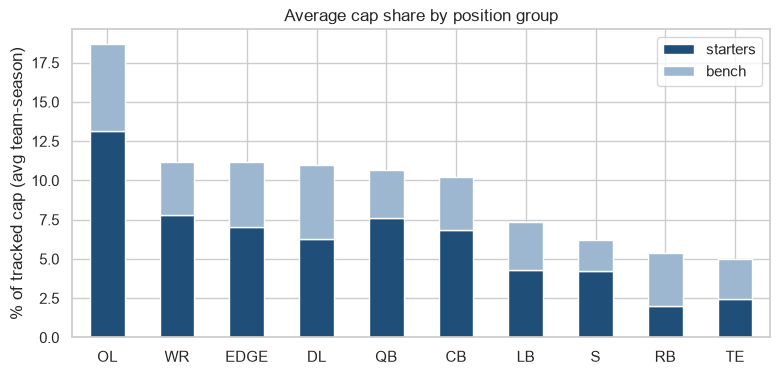

,starters,bench,total
OL,13.100,5.500,18.700
WR,7.800,3.400,11.200
EDGE,7.100,4.100,11.200
DL,6.200,4.800,11.000
QB,7.600,3.100,10.700
CB,6.900,3.400,10.200
LB,4.300,3.000,7.400
S,4.200,2.000,6.200
RB,2.000,3.400,5.400
TE,2.400,2.600,5.000


In [2]:
mix = pd.DataFrame({"starters": [ts[f"{p}_starter_share"].mean() for p in POS],
                    "bench": [ts[f"{p}_bench_share"].mean() for p in POS]}, index=POS) * 100
mix["total"] = mix.sum(axis=1)
mix = mix.sort_values("total", ascending=False)
ax = mix[["starters", "bench"]].plot.bar(stacked=True, figsize=(9, 4), color=["#1f4e79", "#9db7d1"])
ax.set(ylabel="% of tracked cap (avg team-season)", title="Average cap share by position group"); plt.xticks(rotation=0)
plt.show(); mix.round(1)

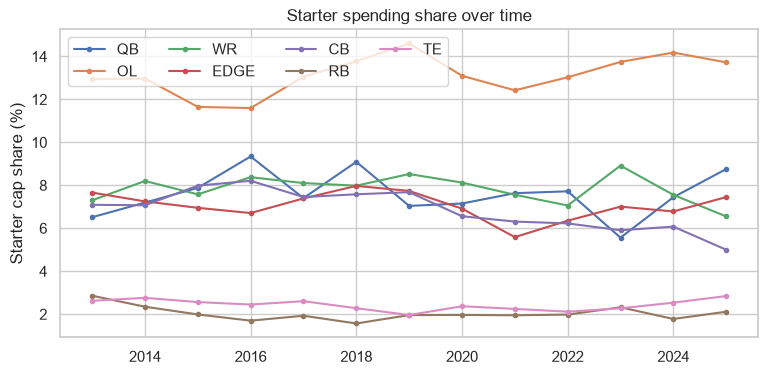

In [3]:
trend = ts.groupby("season")[[f"{p}_st" for p in POS]].mean()
fig, ax = plt.subplots(figsize=(9, 4))
for p in ["QB", "OL", "WR", "EDGE", "CB", "RB", "TE"]:
    ax.plot(trend.index, trend[f"{p}_st"], marker="o", ms=3, label=p)
ax.set(ylabel="Starter cap share (%)", title="Starter spending share over time"); ax.legend(ncol=4); plt.show()

## 2. Which positions' starters matter most? (all positions, one model)

**How to read this:** the baseline is bench/depth spending, so most coefficients are positive almost by construction (starters should beat depth). What matters is the *ranking and the uncertainty*. 1 point of cap share is roughly $1.6M for an average team.

- **QB stands out most reliably:** about +0.31 pts/game per point of cap share, and the interval is tight.
- **TE has the biggest coefficient (+0.44) but a very wide interval.** TE is only about 2% of the cap, so a few teams with elite TEs drive this. Treat it as a hint, not a finding.
- **EDGE, CB and OL** show modest, statistically significant effects (about +0.15 to +0.19).
- **S, DL, LB, RB and WR** are not distinguishable from zero.

The model explains only ~10% of the variance in point differential. Cap allocation is one small piece of what decides seasons.

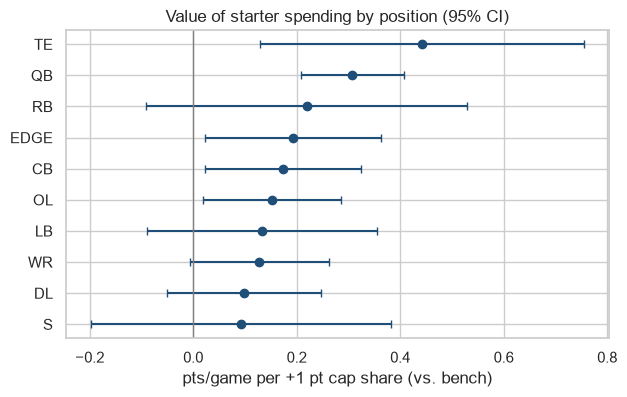

R² = 0.10, n = 416


,coef,lo,hi,p
S,0.092,-0.198,0.382,0.533
DL,0.098,-0.051,0.247,0.199
WR,0.128,-0.007,0.262,0.063
LB,0.133,-0.090,0.356,0.243
OL,0.152,0.018,0.285,0.026
CB,0.173,0.022,0.324,0.024
EDGE,0.193,0.022,0.364,0.027
RB,0.219,-0.092,0.530,0.167
QB,0.307,0.207,0.407,0.000
TE,0.442,0.129,0.755,0.006


In [4]:
# bench spending is the reference group: each coefficient = effect on point diff/game of moving
# +1 point of cap share from bench depth into that position's starters
m_joint = fit("pt_diff_pg ~ " + " + ".join(f"{p}_st" for p in POS) + " + ST_pct")
res = pd.DataFrame({"coef": m_joint.params, "lo": m_joint.conf_int()[0], "hi": m_joint.conf_int()[1],
                    "p": m_joint.pvalues}).loc[[f"{p}_st" for p in POS]]
res.index = POS; res = res.sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(res.coef, range(len(res)), xerr=[res.coef - res.lo, res.hi - res.coef], fmt="o", color="#1f4e79", capsize=3)
ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(res))); ax.set_yticklabels(res.index)
ax.set(xlabel="pts/game per +1 pt cap share (vs. bench)", title="Value of starter spending by position (95% CI)")
plt.show(); print(f"R² = {m_joint.rsquared:.2f}, n = {int(m_joint.nobs)}"); res.round(3)

## 3. Starters vs. bench, position by position

Putting starter and bench spending in the same model per position:

- **QB:** starter spend helps (+0.15, p=0.01) **and bench QB spend hurts** (−0.30, p<0.001). Money tied up in non-starting QBs usually means a failed or injured QB situation.
- **OL:** paying *starters* more shows nothing, but money on OL who are *not* in the top five by snaps is clearly bad (−0.33, p=0.001). That is consistent with injured or benched linemen eating cap.
- **TE:** starter spend again looks positive (+0.38), with the same small-sample caution.
- **WR, RB, DL, EDGE, LB, CB, S:** neither starter nor bench spend is distinguishable from zero here.

*Section 9 digs into the QB and OL bench results: they turn out to be mostly injured-reserve money, not wasted spending.*

In [5]:
rows = []
for p in POS:
    m = fit(f"pt_diff_pg ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"],
                 "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
sb = pd.DataFrame(rows).set_index("pos"); sb.round(3)

,starter_coef,starter_p,bench_coef,bench_p
pos,,,,
QB,0.147,0.012,-0.295,0.000
RB,0.068,0.686,-0.194,0.194
WR,0.018,0.814,-0.197,0.110
TE,0.376,0.027,-0.047,0.800
OL,-0.031,0.718,-0.330,0.001
DL,-0.024,0.776,-0.053,0.611
EDGE,0.081,0.413,0.032,0.763
LB,0.014,0.922,-0.198,0.254
CB,0.003,0.975,-0.020,0.878


## 4. Deep dive: Quarterback

The relationship is strong and nearly monotonic. Teams in the bottom QB-spend quintile average −1.7 pts/game and a 44% win rate. The top two quintiles average about +1.6 to +1.8 pts/game and a 54–56% win rate. **Most of the gain comes by Q4 (about $19M average starter cap); Q5 (about $26M) adds little.**

Caveats the lagged check surfaces: last season's QB share predicts this season's results at about half the same-season effect (0.13 vs 0.23 pts/game per point of share, both significant). So some of the same-season relationship is good QBs getting paid after they play well, but there is still a real forward-looking signal. Whether rookie-scale contracts are driving the result is tested directly in 4b below.

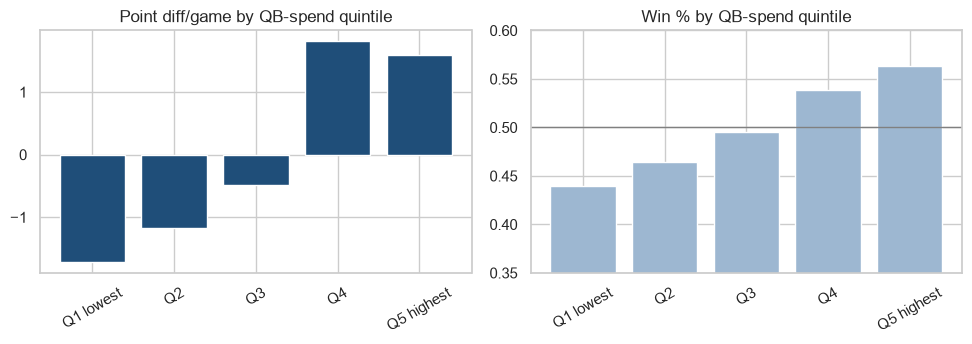

,avg_qb_starter_cap_m,qb_share_pct,win_pct,pt_diff_pg,n
qb_quintile,,,,,
Q1 lowest,1.576,1.005,0.440,-1.713,84
Q2,5.350,3.313,0.464,-1.176,83
Q3,9.290,5.766,0.495,-0.484,83
Q4,18.876,11.447,0.538,1.807,83
Q5 highest,26.326,16.506,0.564,1.598,83


In [6]:
ts["qb_quintile"] = pd.qcut(ts.QB_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
q = ts.groupby("qb_quintile", observed=True).agg(avg_qb_starter_cap_m=("QB_starter", "mean"), qb_share_pct=("QB_st", "mean"),
        win_pct=("win_pct", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(q.index, q.pt_diff_pg, color="#1f4e79"); ax[0].set(title="Point diff/game by QB-spend quintile")
ax[1].bar(q.index, q.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by QB-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); q.round(3)

In [7]:
# is it dollars at QB or just "good teams pay QBs"? try lagged spending (last year's QB share -> this year's results)
ts = ts.sort_values(["team", "season"])
ts["QB_st_lag"] = ts.groupby("team")["QB_st"].shift(1)
lag = fit("pt_diff_pg ~ QB_st_lag", ts.dropna(subset=["QB_st_lag"]))
same = fit("pt_diff_pg ~ QB_st")
print(f"same-season QB starter share: {same.params['QB_st']:.3f} pts/g per pt (p={same.pvalues['QB_st']:.3g})")
print(f"prior-season QB starter share: {lag.params['QB_st_lag']:.3f} pts/g per pt (p={lag.pvalues['QB_st_lag']:.3g})")

# the cheap-QB exception: rookie-deal QBs who played a lot
starters = ps[(ps.pos_group == "QB") & (ps.role == "starter")]
print("\nStarting QBs by cap hit tier (cap $M):")
print(starters.groupby(pd.cut(starters.cap_m, [0, 5, 15, 30, 100])).size())

same-season QB starter share: 0.234 pts/g per pt (p=3.55e-05)
prior-season QB starter share: 0.134 pts/g per pt (p=0.0242)

Starting QBs by cap hit tier (cap $M):
cap_m
(0, 5]       128
(5, 15]      138
(15, 30]     126
(30, 100]     24
dtype: int64


### 4b. Controlling for rookie-contract QBs

**The concern:** QBs on cheap rookie-scale deals are a big group (183 of 416 team-seasons, 44%; median cap hit about $6M vs about $17M for veterans). If rookie-deal QBs happen to be bad, the QB-spend relationship could just be \"cheap QB = young QB = worse\" rather than anything about money.

**Result: it is not.** Adding a rookie-deal flag leaves the QB spend coefficient essentially unchanged (0.234 → 0.240), adding the QB's draft pick as well moves it to 0.257, and the flag itself is about zero (+0.12 pts/game, p=0.87) with no interaction. The slope is about the same within veteran-deal QB1s (0.253, p<0.001) and within rookie-deal QB1s (0.256, though that estimate is noisier, p=0.085). In the all-position model, QB's coefficient goes from 0.307 to 0.299.

So **rookie QBs are not worse on average once you account for how much the team spends on the QB position**: the spending relationship holds *within* both groups.

**A new pattern among veteran-deal QBs:** point differential rises from the cheapest quartile (-2.1, about $4M, often stopgap starters) through the third quartile (+2.9, about $20M), then **drops to +0.8 in the top quartile (about $29M)**. That gap of about 2 pts/game is only about 2 standard errors with 58 team-seasons per bar, so it is suggestive of diminishing returns at the very top, not established. (Section 14 tests this properly in terms of cap share: the taper is real-looking, but a decline is not established.)

*Limits:* the flag is date-based, so it misclassifies a few early extensions (for example, Burrow's 2023 season counts as rookie-scale because he is within 4 years of the draft, though he was already extended). Players on rookie deals who are great and players who are bad are both in the \"rookie\" group, so this separates contract type from QB spend, not QB talent from QB spend.

In [8]:
# rookie-scale = drafted QB within 4 seasons of the draft (5 for 1st-rounders). Defined in src/build_data.py.
ts["rookie"] = ts.qb1_rookie_deal.astype(int)
ts["qb1_pick"] = ts.qb1_draft_overall.fillna(260)   # undrafted = after the last pick
print(ts.groupby("rookie").agg(team_seasons=("team", "size"), qb1_cap_m=("qb1_cap_m", "mean"), qb_share_pct=("QB_st", "mean"),
      pt_diff_pg=("pt_diff_pg", "mean"), win_pct=("win_pct", "mean")).round(2), "\n")

def row(label, m, d):
    return {"model": label, "QB_st coef": m.params["QB_st"], "se": m.bse["QB_st"], "p": m.pvalues["QB_st"], "n": int(m.nobs)}
vet, rk = ts[ts.rookie == 0], ts[ts.rookie == 1]
m1, m2 = fit("pt_diff_pg ~ QB_st"), fit("pt_diff_pg ~ QB_st + rookie")
m2b = fit("pt_diff_pg ~ QB_st + rookie + np.log(qb1_pick)")
m3 = fit("pt_diff_pg ~ QB_st * rookie")
tab = pd.DataFrame([row("1. baseline (no control)", m1, ts), row("2. + rookie-deal flag", m2, ts),
                    row("3. + flag + log(QB1 draft pick)", m2b, ts),
                    row("4. veteran-deal QB1 only", fit("pt_diff_pg ~ QB_st", vet), vet),
                    row("5. rookie-deal QB1 only", fit("pt_diff_pg ~ QB_st", rk), rk)]).set_index("model")
print(f"rookie flag coefficient (model 2): {m2.params['rookie']:.2f} pts/g (p={m2.pvalues['rookie']:.2f}); "
      f"QB_st x rookie interaction (model 3 spec): {m3.params['QB_st:rookie']:.3f} (p={m3.pvalues['QB_st:rookie']:.2f})")
tab.round(3)

        team_seasons  qb1_cap_m  qb_share_pct  pt_diff_pg  win_pct
rookie                                                            
0                233     16.920        10.530       0.640    0.520
1                183      6.320         3.850      -0.810    0.480 

rookie flag coefficient (model 2): 0.12 pts/g (p=0.87); QB_st x rookie interaction (model 3 spec): 0.016 (p=0.91)


,QB_st coef,se,p,n
model,,,,
1. baseline (no control),0.234,0.057,0.000,416
2. + rookie-deal flag,0.240,0.062,0.000,416
3. + flag + log(QB1 draft pick),0.257,0.076,0.001,416
4. veteran-deal QB1 only,0.253,0.063,0.000,233
5. rookie-deal QB1 only,0.256,0.149,0.085,183


QB starter coef: 0.307 -> 0.299 with rookie control (p=3.21e-06); rookie flag: -0.17 (p=0.83)


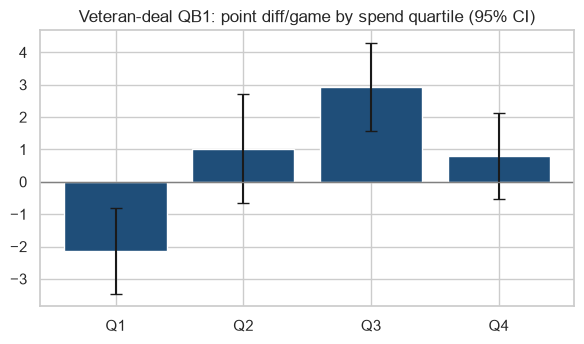

,n,qb1_cap_m,pt_diff_pg,win_pct,se
tier,,,,,
Q1,59,3.810,-2.130,0.420,0.680
Q2,58,15.040,1.020,0.520,0.860
Q3,58,20.270,2.940,0.590,0.690
Q4,58,28.770,0.790,0.540,0.680


In [9]:
# same joint model as section 2, now with the rookie flag: does QB's standing change?
mj = fit("pt_diff_pg ~ " + " + ".join(f"{p}_st" for p in POS) + " + ST_pct + rookie")
print(f"QB starter coef: {m_joint.params['QB_st']:.3f} -> {mj.params['QB_st']:.3f} with rookie control (p={mj.pvalues['QB_st']:.3g}); "
      f"rookie flag: {mj.params['rookie']:.2f} (p={mj.pvalues['rookie']:.2f})")

# among veteran-deal QBs only: is more always better?
v = vet.copy(); v["tier"] = pd.qcut(v.QB_starter_share, 4, labels=["Q1", "Q2", "Q3", "Q4"])
vt = v.groupby("tier", observed=True).agg(n=("team", "size"), qb1_cap_m=("qb1_cap_m", "mean"), pt_diff_pg=("pt_diff_pg", "mean"),
        sd=("pt_diff_pg", "std"), win_pct=("win_pct", "mean"))
vt["se"] = vt.sd / np.sqrt(vt.n)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(vt.index, vt.pt_diff_pg, yerr=1.96 * vt.se, capsize=4, color="#1f4e79")
ax.axhline(0, color="grey", lw=1); ax.set(title="Veteran-deal QB1: point diff/game by spend quartile (95% CI)")
plt.tight_layout(); plt.show(); vt.drop(columns="sd").round(2)

## 5. Deep dive: Wide receiver

WR spend does **not** show the QB pattern. The lowest-spending quintile (about 2.7% of cap) is worst (−1.4 pts/game), but from Q2 upward it is flat: roughly 0 to +0.8 with no trend, and the top quintile (about 14%) is at about 0. That looks like **diminishing returns after a modest level of WR investment**, not a payoff for stars.

Splitting WR spend into the top-paid WR vs. the other starters, neither is distinguishable from zero (top WR +0.04, others −0.03 per point of cap share, wide intervals). Bench WR spend is negative but not significant (−0.20, p=0.11). With 416 team-seasons, we can rule out large WR effects but not small ones.

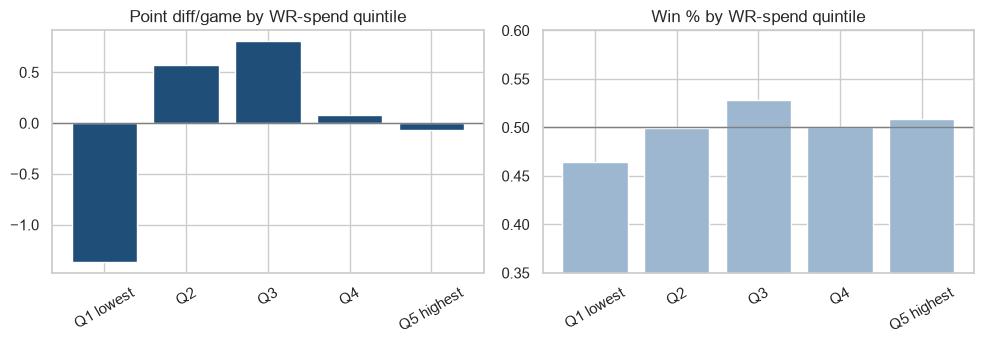

,wr_share_pct,win_pct,pt_diff_pg,n
wr_quintile,,,,
Q1 lowest,2.660,0.465,-1.365,84
Q2,4.979,0.499,0.574,83
Q3,7.218,0.528,0.803,83
Q4,10.015,0.501,0.083,83
Q5 highest,14.341,0.508,-0.067,83


In [10]:
ts["wr_quintile"] = pd.qcut(ts.WR_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
w = ts.groupby("wr_quintile", observed=True).agg(wr_share_pct=("WR_st", "mean"), win_pct=("win_pct", "mean"),
        pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(w.index, w.pt_diff_pg, color="#1f4e79"); ax[0].axhline(0, color="grey", lw=1); ax[0].set(title="Point diff/game by WR-spend quintile")
ax[1].bar(w.index, w.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by WR-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); w.round(3)

In [11]:
# does it matter HOW the WR money is split? top-paid WR vs. the other starting WRs
wr = ps[(ps.pos_group == "WR") & (ps.role == "starter")].copy()
wr["cap_rank"] = wr.groupby(["season", "team"])["cap_m"].rank(ascending=False, method="first")
wr["slot"] = np.where(wr.cap_rank == 1, "WR_top", "WR_other")
split = wr.pivot_table(index=["season", "team"], columns="slot", values="cap_m", aggfunc="sum", fill_value=0).reset_index()
d = ts.merge(split, on=["season", "team"])
d["WR_top_pct"] = d.WR_top / d.tracked_cap_m * 100; d["WR_other_pct"] = d.WR_other / d.tracked_cap_m * 100
m = fit("pt_diff_pg ~ WR_top_pct + WR_other_pct + WR_bn", d)
pd.DataFrame({"coef": m.params, "p": m.pvalues, "lo": m.conf_int()[0], "hi": m.conf_int()[1]}).loc[["WR_top_pct", "WR_other_pct", "WR_bn"]].round(3)

,coef,p,lo,hi
WR_top_pct,0.041,0.715,-0.180,0.263
WR_other_pct,-0.031,0.884,-0.444,0.383
WR_bn,-0.198,0.111,-0.441,0.045


## 6. Robustness

- **Win % as outcome (a):** same story. QB (p=0.005) and TE (p=0.03) are the only positions with significant starter coefficients.
- **Last season's spending (b):** QB (+0.12, p=0.046) and TE (+0.39, p=0.009) survive; everything else stays near zero. Using lagged spending reduces, but does not eliminate, the "good teams just spend more" concern.

In [12]:
# (a) win % as the outcome instead of point differential
rows = []
for p in POS:
    a = fit(f"win_pct ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef_winpct": a.params[f"{p}_st"], "p": a.pvalues[f"{p}_st"]})
pd.DataFrame(rows).set_index("pos").round(4)

,starter_coef_winpct,p
pos,,
QB,0.005,0.005
RB,0.002,0.755
WR,0.001,0.602
TE,0.011,0.030
OL,-0.000,0.965
DL,-0.001,0.646
EDGE,0.002,0.411
LB,-0.000,0.940
CB,-0.001,0.812


In [13]:
# (b) all positions with last season's spending (reduces "good teams spend more" reverse causality)
lagcols = []
for p in POS:
    ts[f"{p}_st_lag"] = ts.groupby("team")[f"{p}_st"].shift(1); lagcols.append(f"{p}_st_lag")
ts["ST_lag"] = ts.groupby("team")["ST_pct"].shift(1)
m_lag = fit("pt_diff_pg ~ " + " + ".join(lagcols) + " + ST_lag", ts.dropna(subset=lagcols))
pd.DataFrame({"coef": m_lag.params, "p": m_lag.pvalues}).loc[lagcols].round(3)

,coef,p
QB_st_lag,0.118,0.046
RB_st_lag,-0.117,0.508
WR_st_lag,-0.015,0.815
TE_st_lag,0.390,0.009
OL_st_lag,0.060,0.435
DL_st_lag,-0.069,0.361
EDGE_st_lag,0.035,0.729
LB_st_lag,-0.039,0.674
CB_st_lag,-0.078,0.482
S_st_lag,-0.006,0.964


## 7. EPA/play: offense vs. defense

Point differential blends offense, defense, and special teams. EPA/play lets us test something sharper: **spending on offensive starters should show up in offensive EPA, and defensive starters in defensive EPA.** Units are EPA per 100 plays, with defense flipped so higher is better for both. Same model as section 2 (bench spending is the baseline).

**What lines up with how football works**
- **QB:** +0.53 offensive EPA per point of cap share (p<0.001), and it is all passing (+0.57 pass vs. +0.02 rush in the position-level models). It does nothing for defense (p=0.40). The rookie-deal control leaves it unchanged (pass EPA 0.711 → 0.703).
- **OL:** +0.34 offensive EPA (p=0.002). In the pass/rush split the gain is in the **run game** (+0.20, p=0.04), not pass blocking (+0.04).
- **EDGE and CB** help the defense (+0.24 and +0.34, both p<0.001), through **pass defense** (EDGE +0.36, CB +0.42 on pass EPA allowed, both p≤0.002).
- **Interior DL** helps the defense (+0.18, p=0.04), through **run defense** (+0.26, p=0.001).
- **S and LB:** no clear effect (LB run defense +0.18, p=0.10).

**Placebo test: it flags TE.** Offensive spending should not move defense and vice versa. Defensive starters never predict offense (all p>0.39), and QB/RB/WR/OL never predict defense (all p>0.4). **TE is the exception: TE spend predicts *defensive* EPA (+0.42, p=0.007) about as strongly as offensive (+0.50, p=0.06).** A tight end cannot cause that, so the TE result in sections 2, 3 and 6 is most likely noise or a proxy for something else, such as a few well-run teams. I'm downgrading it.

**WR is the main revision to earlier conclusions.** On point differential, WR spend looked flat (section 5). On offensive EPA it shows a modest but real effect (+0.29, p=0.002 in the joint model; +0.30 on pass EPA, p=0.056). Point differential was too blunt to detect it. Read section 5's \"no payoff\" as \"no *large* payoff\".

**A caution:** this section tests 10 positions across several outcomes, so a few p<0.05 results are expected by chance, and the pass/rush splits are exploratory. What gives confidence is the *pattern*: effects land on the right side of the ball and the right phase of the game, and the placebo test holds for every position except TE.

In [14]:
# EPA per 100 plays; defense is flipped so that HIGHER = BETTER for both sides
ts["off"] = ts.off_epa_play * 100
ts["off_pass"], ts["off_rush"] = ts.off_pass_epa_play * 100, ts.off_rush_epa_play * 100
ts["dfn"] = -ts.def_epa_play * 100
ts["dfn_pass"], ts["dfn_rush"] = -ts.def_pass_epa_play * 100, -ts.def_rush_epa_play * 100
print("corr with point diff/game:", ts[["off", "dfn"]].corrwith(ts.pt_diff_pg).round(2).to_dict())

rhs = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"      # same spec as section 2 (bench = reference)
joint = {name: fit(f"{y} ~ {rhs}") for name, y in [("point diff", "pt_diff_pg"), ("offense EPA", "off"), ("defense EPA", "dfn")]}
cols = [f"{p}_st" for p in POS]
tab = pd.concat({k: pd.DataFrame({"coef": m.params[cols], "p": m.pvalues[cols]}) for k, m in joint.items()}, axis=1)
tab.index = POS
tab.round(3)

corr with point diff/game: {'off': 0.78, 'dfn': 0.62}


point diff       offense EPA       defense EPA      
           coef     p        coef     p        coef     p
QB        0.307 0.000       0.525 0.000       0.045 0.401
RB        0.219 0.167       0.283 0.133       0.114 0.546
WR        0.128 0.063       0.294 0.002      -0.029 0.721
TE        0.442 0.006       0.503 0.063       0.422 0.007
OL        0.152 0.026       0.337 0.002      -0.006 0.929
DL        0.098 0.199       0.060 0.565       0.180 0.037
EDGE      0.193 0.027       0.140 0.396       0.241 0.000
LB        0.133 0.243       0.036 0.793       0.166 0.221
CB        0.173 0.024      -0.018 0.881       0.341 0.000
S         0.092 0.533       0.092 0.633       0.113 0.432

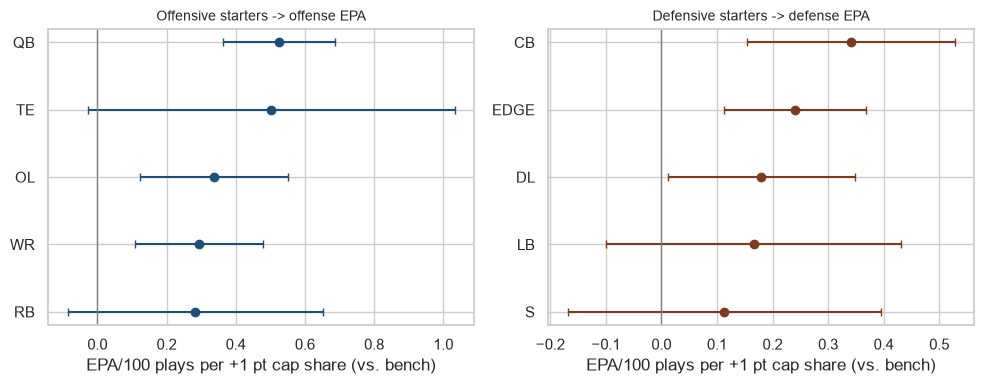

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
off_pos, def_pos = ["QB", "RB", "WR", "TE", "OL"], ["DL", "EDGE", "LB", "CB", "S"]
for ax, key, plist, color, title in [(axes[0], "offense EPA", off_pos, "#1f4e79", "Offensive starters -> offense EPA"),
                                     (axes[1], "defense EPA", def_pos, "#7a3b1f", "Defensive starters -> defense EPA")]:
    m = joint[key]; ci = m.conf_int().loc[[f"{p}_st" for p in plist]]; c = m.params[[f"{p}_st" for p in plist]]
    order = c.sort_values().index
    ax.errorbar(c[order], range(len(order)), xerr=[c[order] - ci.loc[order, 0], ci.loc[order, 1] - c[order]], fmt="o", color=color, capsize=3)
    ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(order))); ax.set_yticklabels([o.replace("_st", "") for o in order]); ax.set_title(title, fontsize=10)
    ax.set_xlabel("EPA/100 plays per +1 pt cap share (vs. bench)")
plt.tight_layout(); plt.show()

In [16]:
# mechanism check: split each side into pass and rush EPA, and show starter vs bench spend for the relevant positions
rows = []
for p in off_pos:
    for y, lab in [("off_pass", "off pass EPA"), ("off_rush", "off rush EPA")]:
        m = fit(f"{y} ~ {p}_st + {p}_bn"); rows.append({"pos": p, "outcome": lab, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"], "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
for p in def_pos:
    for y, lab in [("dfn_pass", "def pass EPA"), ("dfn_rush", "def rush EPA")]:
        m = fit(f"{y} ~ {p}_st + {p}_bn"); rows.append({"pos": p, "outcome": lab, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"], "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
mech = pd.DataFrame(rows).set_index(["pos", "outcome"]); mech.round(3)

starter_coef  starter_p  bench_coef  bench_p
pos  outcome                                                   
QB   off pass EPA         0.573      0.000      -0.467    0.001
     off rush EPA         0.015      0.845      -0.238    0.000
RB   off pass EPA        -0.079      0.800      -0.569    0.035
     off rush EPA         0.334      0.062       0.046    0.760
WR   off pass EPA         0.295      0.056      -0.117    0.633
     off rush EPA        -0.027      0.815      -0.050    0.712
TE   off pass EPA         0.529      0.217      -0.276    0.435
     off rush EPA         0.399      0.044       0.009    0.958
OL   off pass EPA         0.039      0.811      -0.655    0.002
     off rush EPA         0.195      0.038      -0.259    0.025
DL   def pass EPA         0.070      0.642       0.087    0.626
     def rush EPA         0.256      0.001      -0.067    0.575
EDGE def pass EPA         0.355      0.002       0.181    0.206
     def rush EPA         0.005      0.953      -0.139    0.171
LB   def pass EPA        -0.056      0.789      -0.317    0.124
     def rush EPA         0.183      0.097      -0.165    0.354
CB   def pass EPA         0.424      0.001      -0.146    0.276
     def rush EPA         0.055      0.632      -0.002    0.987
S    def pass EPA         0.017      0.947      -0.026    0.930
     def rush EPA        -0.082      0.457       0.012    0.956

In [17]:
# QB check: does the rookie-contract control still leave a QB -> offense effect?
for y in ["off", "off_pass"]:
    a, b = fit(f"{y} ~ QB_st"), fit(f"{y} ~ QB_st + rookie")
    print(f"{y:9s}: QB_st {a.params['QB_st']:.3f} (p={a.pvalues['QB_st']:.3g}) -> with rookie flag {b.params['QB_st']:.3f} (p={b.pvalues['QB_st']:.3g})")

off      : QB_st 0.461 (p=3.01e-08) -> with rookie flag 0.492 (p=5.01e-08)
off_pass : QB_st 0.711 (p=1.32e-09) -> with rookie flag 0.703 (p=3.54e-07)


## 8. Sensitivity to the starter definition

Everything so far uses one definition of \"starter\" (top-N by snaps, filling a base 11-man lineup). Here I rerun the key findings under five alternatives: a *narrower* lineup (WR2, CB2, LB1), a *wider* one (RB2, WR4, TE2, OL6, DL3, EDGE3, LB3, CB4, S3), and snap-share cutoffs of 33%, 50% and 66%. Definitions change the *scale* of each position's starter share, so the heatmap shows the effect of a one-standard-deviation shift, which is comparable across definitions. This is a robustness check on my own choices, not independent evidence, since it is the same data each time.

**What holds under every definition**
- **QB**: significant for both point differential and offensive EPA in all six (about +1.7 to +2.1 pts/game and +2.6 to +3.3 EPA/100 plays per 1 SD).
- **WR, OL → offense** and **EDGE, CB → defense**: significant in all six.
- **Non-starting QB and OL money is negative** in all six (all p≤0.001), so that finding does not depend on where the starter line is drawn.

**What is fragile**
- **Interior DL → defense** is significant in only 4 of 6 (not under the narrow lineup or the 66% cutoff). Treat it as the weakest of the defensive findings.
- **TE → offense** is significant in only 2 of 6 (the 50% and 66% cutoffs), so it never held up reliably. Meanwhile the **TE → defense placebo "effect" shows up in 5 of 6**, which reinforces treating TE as noise rather than a real effect.

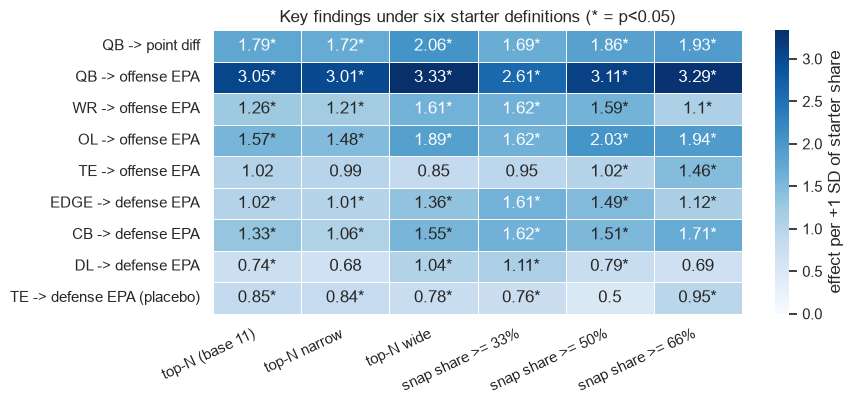

avg starters per team-season: {'top-N (base 11)': np.float64(22.0), 'top-N narrow': np.float64(19.0), 'top-N wide': np.float64(30.9), 'snap share >= 33%': np.float64(27.4), 'snap share >= 50%': np.float64(19.5), 'snap share >= 66%': np.float64(13.3)}


,QB bench coef,QB bench p,OL bench coef,OL bench p
top-N (base 11),-0.295,0.000,-0.330,0.001
top-N narrow,-0.295,0.000,-0.330,0.001
top-N wide,-0.295,0.000,-0.446,0.000
snap share >= 33%,-0.314,0.000,-0.412,0.000
snap share >= 50%,-0.299,0.000,-0.370,0.000
snap share >= 66%,-0.273,0.000,-0.346,0.000


In [18]:
import sys; sys.path.insert(0, "src")
from build_data import STARTER_RULES, assign_roles, share_table

outcomes = ts[["season", "team", "pt_diff_pg", "off", "dfn"]]
FINDINGS = [("QB -> point diff", "pt_diff_pg", "QB_st"), ("QB -> offense EPA", "off", "QB_st"), ("WR -> offense EPA", "off", "WR_st"),
            ("OL -> offense EPA", "off", "OL_st"), ("TE -> offense EPA", "off", "TE_st"), ("EDGE -> defense EPA", "dfn", "EDGE_st"),
            ("CB -> defense EPA", "dfn", "CB_st"), ("DL -> defense EPA", "dfn", "DL_st"), ("TE -> defense EPA (placebo)", "dfn", "TE_st")]
JOINT_RHS = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"

def rebuild(rule):
    p = ps.copy(); p["role"] = assign_roles(p, rule)
    d = share_table(p).merge(outcomes, on=["season", "team"])
    for q in POS:
        d[f"{q}_st"], d[f"{q}_bn"] = d[f"{q}_starter_share"] * 100, d[f"{q}_bench_share"] * 100
    d["ST_pct"] = d.ST_all_share * 100
    return d, p[p.role == "starter"].groupby(["season", "team"]).size().mean()

effect, stars, bench, nstart = {}, {}, {}, {}
for name, rule in STARTER_RULES.items():
    d, nstart[name] = rebuild(rule)
    joint_fits = {y: fit(f"{y} ~ {JOINT_RHS}", d) for y in ["pt_diff_pg", "off", "dfn"]}
    effect[name], stars[name] = {}, {}
    for label, y, v in FINDINGS:
        m = joint_fits[y]
        effect[name][label] = m.params[v] * d[v].std()          # pts or EPA/100 per +1 SD of that position's starter share
        stars[name][label] = "*" if m.pvalues[v] < 0.05 else ""
    qb, ol = fit("pt_diff_pg ~ QB_st + QB_bn", d), fit("pt_diff_pg ~ OL_st + OL_bn", d)
    bench[name] = {"QB bench coef": qb.params["QB_bn"], "QB bench p": qb.pvalues["QB_bn"],
                   "OL bench coef": ol.params["OL_bn"], "OL bench p": ol.pvalues["OL_bn"]}

E, S = pd.DataFrame(effect), pd.DataFrame(stars)
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(E, annot=E.round(2).astype(str) + S, fmt="", cmap="Blues", vmin=0, cbar_kws={"label": "effect per +1 SD of starter share"}, ax=ax, linewidths=.5)
ax.set(title="Key findings under six starter definitions (* = p<0.05)", xlabel="", ylabel="")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
print("avg starters per team-season:", {k: round(v, 1) for k, v in nstart.items()})
pd.DataFrame(bench).T.round(3)

## 9. Why is non-starter QB and OL money so negative?

Section 3 found that cap tied up in non-starting QBs and OL goes with *worse* results. That could mean (1) **injuries** (the expensive starter got hurt, so his cap hit becomes \"bench\" money), (2) **selection** (bad teams just look different), or (3) **real waste** (overpaid depth). To separate them I split every non-starter's cap by *why* he isn't a starter, using weekly roster status and snaps. This section uses 2016+ only, because injured-reserve weeks look undercounted in 2013-15 (about 0.9 per player vs. 1.7+ afterwards).

**1. Injured-reserve money is the main driver for both positions, and it is mechanical.**
A 1-SD higher IR cap share costs about 1.2 pts/game in the same season (QB −1.20, OL −1.24, both p<0.001). But *last* season's IR money does not predict this season (QB +0.09, p=0.85; OL −0.26, p=0.57). That is the signature of an injury effect: the star got hurt and the team suffered *that year*. It is not evidence of bad roster decisions. The same pattern shows up for backup QBs who actually played (−0.62 same-season, −0.12 prior-season): a backup played because the starter was out.

**2. Healthy OL who never play also look bad, but mostly as a proxy for team quality.**
This group (no snaps, not on IR, not cut) is small money (about $0.8M per player), yet it has a large same-season effect (−1.28 per SD, p<0.001) that *does* carry into the next season (−0.87, p=0.004). That persistence looks like roster-building rather than injury. However, controlling for last season's point differential cuts it from −0.65 to −0.27 and it is no longer significant (p=0.34), so it mostly reflects bad teams staying bad. Early-round rookie linemen who sit are a tiny group (16 player-seasons, 17% of this money, about $3.2M each). Their effect is bigger and survives the control (−1.10, p=0.03), but 16 observations is too few to lean on.

**3. Cut and practice-squad money** (the closest thing to dead cap we can see) is negligible for both positions.

**Bottom line:** the \"wasted bench money\" reading of section 3 is mostly wrong. The signal is largely **injuries**, plus a **team-quality proxy**. It does not show that expensive depth is waste, and it does not show that depth is worth paying for either. What it does show is the *cost of injury exposure* at QB and OL.

*Caveats:* the 4-week IR cutoff is a judgment call, roster-status coding may be imperfect, \"idle\" can include players who were hurt but never placed on IR, and all of this is observational.

In [19]:
# split every non-starter's cap into WHY he isn't a starter, using weekly roster status and snaps:
#   ir          = 4+ regular-season weeks on injured reserve / PUP / NWT
#   played      = not a top-N starter but took snaps
#   idle_roster = no snaps, mostly on the active/inactive roster (healthy scratch, developmental)
#   idle_cut    = no snaps, mostly off the active roster (cut / practice squad)
# IR weeks look undercounted in 2013-15 (check below), so this section uses 2016+.
print("avg IR weeks per player-season:", ps.groupby("season").weeks_ir.mean().round(2).to_dict())
off_roster = ps.weeks_other > (ps.weeks_act + ps.weeks_ina)
ps["cat"] = np.select([ps.role == "starter", ps.weeks_ir >= 4, ps.unit_snaps > 0, off_roster],
                      ["starter", "ir", "played", "idle_cut"], "idle_roster")
CATS = ["starter", "ir", "played", "idle_roster", "idle_cut"]

def cat_shares(pos):
    t = ps[ps.pos_group == pos].pivot_table(index=["season", "team"], columns="cat", values="cap_m", aggfunc="sum", fill_value=0)
    t = t.reindex(columns=CATS, fill_value=0).div(ts.set_index(["season", "team"]).tracked_cap_m, axis=0) * 100
    t.columns = [f"c_{pos}_{c}" for c in CATS]
    return t.reset_index()

for pos in ["QB", "OL"]:
    ts = ts.merge(cat_shares(pos), on=["season", "team"], how="left")
ts = ts.sort_values(["team", "season"])
d16 = ts[ts.season >= 2016]

summary = (ps[ps.pos_group.isin(["QB", "OL"]) & (ps.season >= 2016)].groupby(["pos_group", "cat"])
           .agg(player_seasons=("cap_m", "size"), avg_cap_m=("cap_m", "mean"), total_cap_m=("cap_m", "sum")).round(2))
summary

avg IR weeks per player-season: {2013: 0.88, 2014: 0.92, 2015: 1.02, 2016: 1.63, 2017: 1.76, 2018: 1.7, 2019: 1.77, 2020: 1.76, 2021: 2.09, 2022: 1.77, 2023: 1.68, 2024: 1.9, 2025: 2.02}


player_seasons  avg_cap_m  total_cap_m
pos_group cat                                                
OL        idle_cut                692      0.130       93.310
          idle_roster             358      0.820      294.050
          ir                      621      2.420     1500.860
          played                 1167      1.090     1269.950
          starter                1600      4.620     7395.420
QB        idle_cut                163      0.140       23.620
          idle_roster             134      0.850      113.870
          ir                       98      6.810      667.660
          played                  417      2.260      941.190
          starter                 320     13.410     4291.590

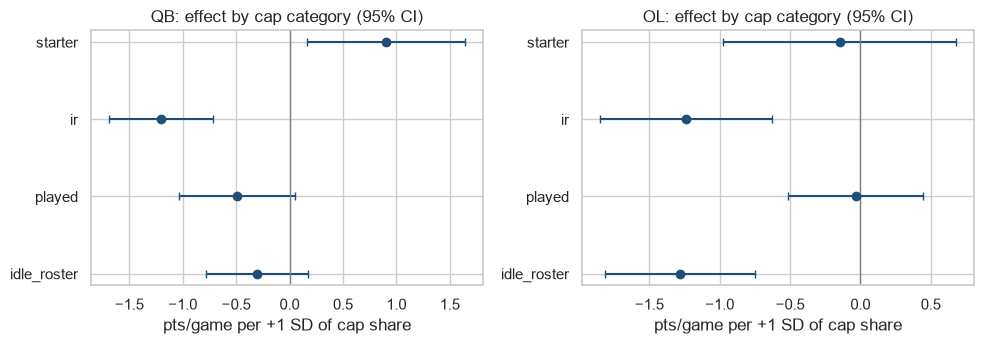

QB                                OL                \
            effect_per_sd     lo     hi     p effect_per_sd     lo     hi   
starter             0.902  0.159  1.644 0.017        -0.147 -0.974  0.681   
ir                 -1.203 -1.690 -0.715 0.000        -1.239 -1.850 -0.628   
played             -0.492 -1.038  0.053 0.077        -0.034 -0.513  0.446   
idle_roster        -0.306 -0.783  0.171 0.208        -1.283 -1.816 -0.749   
idle_cut           -0.234 -0.964  0.496 0.530         0.036 -0.288  0.360   

                   
                p  
starter     0.728  
ir          0.000  
played      0.891  
idle_roster 0.000  
idle_cut    0.829

In [20]:
# same-season effects, 2016+: effect on point diff/game of a 1-SD higher cap share in each category
def effects(pos, data, lagged=False):
    suffix = "_lag" if lagged else ""
    cs = [f"c_{pos}_{c}{suffix}" for c in CATS]
    m = fit("pt_diff_pg ~ " + " + ".join(cs), data)
    sd = data[cs].std()
    return pd.DataFrame({"effect_per_sd": m.params[cs] * sd, "lo": (m.params[cs] - 1.96 * m.bse[cs]) * sd,
                         "hi": (m.params[cs] + 1.96 * m.bse[cs]) * sd, "p": m.pvalues[cs]}).set_axis(CATS)

same = {pos: effects(pos, d16) for pos in ["QB", "OL"]}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, pos in zip(axes, ["QB", "OL"]):
    e = same[pos].drop(index="idle_cut")[::-1]
    ax.errorbar(e.effect_per_sd, range(len(e)), xerr=[e.effect_per_sd - e.lo, e.hi - e.effect_per_sd], fmt="o", color="#1f4e79", capsize=3)
    ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(e))); ax.set_yticklabels(e.index)
    ax.set(title=f"{pos}: effect by cap category (95% CI)", xlabel="pts/game per +1 SD of cap share")
plt.tight_layout(); plt.show()
pd.concat(same, axis=1).round(3)

In [21]:
# is it mechanical (this year's injury hurts this year) or persistent (a roster-building flaw)?
# if persistent, LAST season's money in the category should predict THIS season's results too
for pos in ["QB", "OL"]:
    for c in CATS:
        ts[f"c_{pos}_{c}_lag"] = ts.groupby("team")[f"c_{pos}_{c}"].shift(1)
d17 = ts[ts.season >= 2017]
persist = pd.concat({pos: pd.DataFrame({"same_season": effects(pos, d17).effect_per_sd, "same_p": effects(pos, d17).p,
                                        "prior_season": effects(pos, d17, lagged=True).effect_per_sd, "prior_p": effects(pos, d17, lagged=True).p})
                     for pos in ["QB", "OL"]}, axis=1)
persist.round(3)

QB                                      OL         \
            same_season same_p prior_season prior_p same_season same_p   
starter           0.870  0.023        0.572   0.136      -0.154  0.737   
ir               -1.185  0.000        0.093   0.848      -1.316  0.000   
played           -0.617  0.031       -0.118   0.707      -0.003  0.991   
idle_roster      -0.221  0.493       -0.318   0.246      -1.056  0.001   
idle_cut         -0.233  0.547        0.021   0.960       0.022  0.892   

                                  
            prior_season prior_p  
starter            0.365   0.469  
ir                -0.259   0.571  
played            -0.438   0.258  
idle_roster       -0.869   0.004  
idle_cut           0.292   0.163

In [22]:
# OL "idle" money: selection check. (a) is it just high-drafted rookies on bad teams? (b) does it survive controlling for last year's record?
ps["cat2"] = np.where((ps.cat == "idle_roster") & (ps.pos_group == "OL") & ps.rookie_deal & (ps.draft_round <= 2), "idle_early", ps.cat)
idle = ps[(ps.pos_group == "OL") & (ps.season >= 2016) & ps.cat.eq("idle_roster")]
early = idle.rookie_deal & (idle.draft_round <= 2)
print(f"idle-roster OL: {len(idle)} player-seasons, ${idle.cap_m.sum():.0f}M; rookie-deal rounds 1-2 are {early.sum()} of them "
      f"({idle[early].cap_m.sum() / idle.cap_m.sum():.0%} of the money, avg ${idle[early].cap_m.mean():.1f}M vs ${idle[~early].cap_m.mean():.1f}M for the rest)")

t = ps[ps.pos_group == "OL"].pivot_table(index=["season", "team"], columns="cat2", values="cap_m", aggfunc="sum", fill_value=0)
t = t.reindex(columns=CATS + ["idle_early"], fill_value=0).div(ts.set_index(["season", "team"]).tracked_cap_m, axis=0) * 100
t.columns = [f"o_{c}" for c in t.columns]
d = ts.merge(t.reset_index(), on=["season", "team"])
d["prev_pd"] = d.groupby("team").pt_diff_pg.shift(1)
d = d[d.season >= 2017]
cs = ["o_starter", "o_ir", "o_played", "o_idle_roster", "o_idle_early", "o_idle_cut"]
a, b = fit("pt_diff_pg ~ " + " + ".join(cs), d), fit("pt_diff_pg ~ prev_pd + " + " + ".join(cs), d)
sel = pd.DataFrame({"coef (no control)": a.params[cs], "p ": a.pvalues[cs], "coef (+ last season's pt diff)": b.params[cs], "p": b.pvalues[cs]})
print(f"last season's point diff coefficient: {b.params['prev_pd']:.2f} (p={b.pvalues['prev_pd']:.3g}); n={int(b.nobs)}; idle_early is only {int(early.sum())} player-seasons")
sel.round(3)

idle-roster OL: 358 player-seasons, $294M; rookie-deal rounds 1-2 are 16 of them (17% of the money, avg $3.2M vs $0.7M for the rest)
last season's point diff coefficient: 0.39 (p=3.59e-09); n=288; idle_early is only 16 player-seasons


,coef (no control),p,coef (+ last season's pt diff),p
o_starter,-0.041,0.668,0.034,0.659
o_ir,-0.399,0.000,-0.279,0.000
o_played,-0.021,0.895,0.173,0.240
o_idle_roster,-0.645,0.025,-0.269,0.340
o_idle_early,-1.731,0.001,-1.104,0.030
o_idle_cut,0.128,0.818,0.024,0.959


## 10. The insurance question: do pricier backup QBs cushion an injury?

Section 9 showed that injuries at QB are costly. This asks the follow-up: **does paying more for the backup QB reduce the damage when the starter goes down?**

**Design.** The *intended starter* is the highest-cap QB who was on the roster most of the season (so a QB cut early, or signed after an injury, does not count). The *backup* is the next-highest-cap QB on that roster. Backup cap is set before the injury, so \"pricier backup\" is a decision the team made in advance. Exposure is weeks the starter spent on injured reserve or inactive. The key term is the interaction between weeks missed and backup cap. 2016+ only (injured-reserve coverage), 320 team-seasons.

**The cost of losing the starter is large.** Each missed week costs about 0.64 pts/game (p<0.001), so 8 missed weeks is roughly 5 pts/game, and about 1.1 EPA/100 plays on offense per week.

**But pricier backups show no detectable cushion.**
- The interaction is essentially zero on point differential (+0.011 per $1M per week, p=0.55). On offensive EPA it leans slightly positive (+0.065, p=0.07; passing +0.093, p=0.08), which is the only hint of insurance value, and it does not show up in point differential.
- In the 76 seasons where the starter missed 4+ weeks, point differential is -3.6, -3.5 and -3.9 for the cheapest, middle and priciest thirds of backups (about 25 seasons each, standard errors of about 1).
- Three robustness variants agree (a >=$5M backup dummy p=0.73, snap-based exposure p=0.37, 2018+ only p=0.77).

**What we can and cannot conclude.** This is a precise \"no\" only for large effects. A +$5M backup in a season where the starter misses 8 weeks is worth -0.25 pts/game, with a 95% interval of -1.5 to +1.0. Since 8 missed weeks costs about 5 pts/game, a $5M backup recovers **at most about a fifth of the damage**; for a $10M backup the upper bound is about +2 pts/game (two-fifths). So modest insurance value is not ruled out, and the data are thin: the median backup costs $1.8M, only 33 backups cost $5M+, and just 16 of those were needed for 4+ weeks.

*Caveats:* this section proxies backup *quality* by cap hit (section 11 measures it directly and reaches the same conclusion), and the backup who actually played is not always the one the team planned on.

In [23]:
# intended starter = highest-cap QB on the roster for most of the year (so a QB cut early, or signed after an injury, doesn't count)
# backup = next-highest-cap QB on that roster. Cap is set BEFORE the injury, so "pricier backup" is an ex-ante choice. 2016+ (IR coverage).
q = ps[(ps.pos_group == "QB") & (ps.season >= 2016)].copy()
q = q[(q.weeks_act + q.weeks_ina + q.weeks_ir) >= 10]
rows = []
for (season, team), g in q.sort_values("cap_m", ascending=False).groupby(["season", "team"]):
    a, b = g.iloc[0], (g.iloc[1] if len(g) > 1 else None)
    rows.append({"season": season, "team": team, "qb1_cap": a.cap_m, "missed": a.weeks_ir + a.weeks_ina, "qb1_snap_share": a.off_share,
                 "qb2_cap": 0.0 if b is None else b.cap_m, "qb1_gsis": a.gsis_id, "qb2_gsis": None if b is None else b.gsis_id, "qb2_name": None if b is None else b.player,
                 "qb2_pick": 260 if (b is None or pd.isna(b.draft_overall)) else b.draft_overall})
ins = pd.DataFrame(rows).merge(ts[["season", "team", "pt_diff_pg", "off", "off_pass"]], on=["season", "team"])
ins["backup_ge5"] = (ins.qb2_cap >= 5).astype(int)
print(f"{len(ins)} team-seasons | starter missed 3+ weeks: {(ins.missed >= 3).sum()}, 4+ weeks: {(ins.missed >= 4).sum()} | "
      f"backup cap median ${ins.qb2_cap.median():.1f}M, 90th pct ${ins.qb2_cap.quantile(.9):.1f}M; backups >= $5M: {ins.backup_ge5.sum()}")
print(f"corr(starter cap, backup cap) = {ins.qb1_cap.corr(ins.qb2_cap):.2f}  (teams with pricey starters do not systematically buy pricey backups)")
ins[["missed", "qb1_cap", "qb2_cap"]].describe().round(1).T

320 team-seasons | starter missed 3+ weeks: 91, 4+ weeks: 76 | backup cap median $1.8M, 90th pct $5.0M; backups >= $5M: 33
corr(starter cap, backup cap) = -0.04  (teams with pricey starters do not systematically buy pricey backups)


,count,mean,std,min,25%,50%,75%,max
missed,320.000,2.300,3.800,0.000,0.000,0.000,3.000,17.000
qb1_cap,320.000,15.700,10.600,0.600,6.900,14.000,22.300,50.500
qb2_cap,320.000,2.400,2.100,0.000,0.900,1.800,3.000,21.300


In [24]:
# model: outcome ~ weeks starter missed x backup cap ($M), controlling for the starter's own cap, with season FE.
#   'missed'          = cost of each missed week with a ~$0 backup
#   'missed:qb2_cap'  = how much each extra $1M of backup cap shrinks that cost  (>0 would mean insurance value)
fits = {y: fit(f"{y} ~ missed * qb2_cap + qb1_cap", ins) for y in ["pt_diff_pg", "off", "off_pass"]}
tab = pd.DataFrame({y: {"cost per missed week": m.params["missed"], "p (cost)": m.pvalues["missed"],
                        "insurance per $1M backup per week": m.params["missed:qb2_cap"], "p (insurance)": m.pvalues["missed:qb2_cap"]}
                    for y, m in fits.items()}).T

def implied(m, weeks, cap):
    # total effect of a `cap`-$M backup in a season where the starter missed `weeks` weeks (main effect + interaction), with 95% CI
    w = pd.Series(0.0, index=m.params.index); w["qb2_cap"] = cap; w["missed:qb2_cap"] = weeks * cap
    est, se = (w * m.params).sum(), np.sqrt(w.values @ m.cov_params().values @ w.values)
    return est, est - 1.96 * se, est + 1.96 * se

m = fits["pt_diff_pg"]
print(f"typical damage from 8 missed weeks (avg backup): {8 * m.params['missed']:.1f} pts/game\n")
for weeks, cap in [(4, 5), (8, 5), (8, 10)]:
    est, lo, hi = implied(m, weeks, cap)
    print(f"+${cap}M backup, starter out {weeks} wks: {est:+.2f} pts/g, 95% CI [{lo:+.2f}, {hi:+.2f}]")
tab.round(3)

typical damage from 8 missed weeks (avg backup): -5.1 pts/game

+$5M backup, starter out 4 wks: -0.48 pts/g, 95% CI [-1.86, +0.90]
+$5M backup, starter out 8 wks: -0.25 pts/g, 95% CI [-1.52, +1.01]
+$10M backup, starter out 8 wks: -0.51 pts/g, 95% CI [-3.04, +2.03]


,cost per missed week,p (cost),insurance per $1M backup per week,p (insurance)
pt_diff_pg,-0.637,0.000,0.011,0.552
off,-1.133,0.000,0.065,0.067
off_pass,-1.583,0.000,0.093,0.078


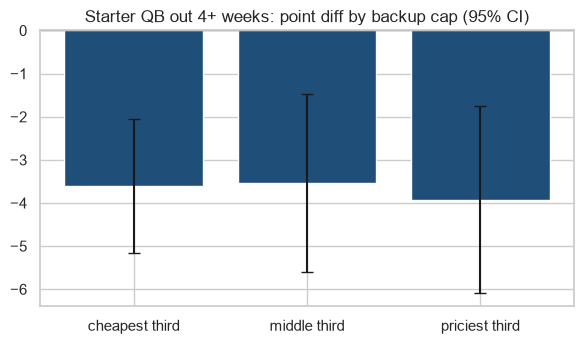

,n,backup_cap_m,starter_cap_m,weeks_missed,pt_diff_pg,off_epa100,se
backup_tier,,,,,,,
cheapest third,26,0.840,16.760,7.880,-3.600,-6.590,0.790
middle third,25,2.150,16.260,7.040,-3.540,-5.570,1.050
priciest third,25,5.910,15.480,9.320,-3.930,-5.670,1.110


In [25]:
# the cleanest look: only seasons where the starter was actually out 4+ weeks, backups split into thirds by cap
out = ins[ins.missed >= 4].copy()
out["backup_tier"] = pd.qcut(out.qb2_cap, 3, labels=["cheapest third", "middle third", "priciest third"])
t = out.groupby("backup_tier", observed=True).agg(n=("team", "size"), backup_cap_m=("qb2_cap", "mean"), starter_cap_m=("qb1_cap", "mean"),
        weeks_missed=("missed", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), sd=("pt_diff_pg", "std"), off_epa100=("off", "mean"))
t["se"] = t.sd / np.sqrt(t.n)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(t.index, t.pt_diff_pg, yerr=1.96 * t.se, capsize=4, color="#1f4e79"); ax.axhline(0, color="grey", lw=1)
ax.set(title="Starter QB out 4+ weeks: point diff by backup cap (95% CI)"); plt.tight_layout(); plt.show()
t.drop(columns="sd").round(2)

In [26]:
# robustness: three other ways to ask the same question
a = fit("pt_diff_pg ~ missed * backup_ge5 + qb1_cap", ins)                                # a >=$5M backup vs. cheaper
ins["away"] = 1 - ins.qb1_snap_share                                                       # share of snaps the starter did NOT play (injury or benching)
b = fit("pt_diff_pg ~ away * qb2_cap + qb1_cap", ins)
c = fit("pt_diff_pg ~ missed * qb2_cap + qb1_cap", ins[ins.season >= 2018])                # drop the first two seasons
pd.DataFrame({"interaction coef": [a.params["missed:backup_ge5"], b.params["away:qb2_cap"], c.params["missed:qb2_cap"]],
              "p": [a.pvalues["missed:backup_ge5"], b.pvalues["away:qb2_cap"], c.pvalues["missed:qb2_cap"]]},
             index=["backup >= $5M x weeks missed", "snap-based exposure x backup cap", "2018+ only"]).round(3)

,interaction coef,p
backup >= $5M x weeks missed,-0.044,0.728
snap-based exposure x backup cap,-0.242,0.365
2018+ only,0.006,0.771


## 11. Backup quality, measured directly

Section 10 used cap hit as a stand-in for backup quality. Here quality is measured directly, using only information from **before** the season, in three ways: **prior EPA** (the QB's career EPA per 100 pass plays through last season, shrunk toward the league average so a QB with 30 plays is not judged on 30 plays), **experience** (career pass plays), and **draft pedigree** (log of draft pick, where lower is better).

**The measure carries real signal.** Across 328 QB-seasons with a track record, prior EPA correlates 0.47 with the same QB's EPA the next year (slope 0.85). It is also only weakly related to cap hit (0.08), so it is genuinely a different measure.

**The answer is the same: no detectable cushion.**
- The interaction between weeks missed and backup quality is near zero for point differential under every measure (prior EPA p=0.65, experience p=0.96, draft pedigree p=0.61).
- Split by the backup's prior EPA, seasons where the starter was out 4+ weeks score -4.4, -2.9 and -3.7 pts/game for the lowest, middle and highest thirds (about 25 seasons each). There is no gradient.
- A backup one standard deviation better, with the starter out 8 weeks, changes point differential by -0.3 (interval -1.4 to +0.8) on prior EPA and +0.3 (-0.6 to +1.3) on draft pedigree. Since 8 missed weeks costs about 5 pts/game, **on point differential, even the most generous end of any interval is about a quarter of the damage.**

**Two things not to over-read.**
- On offensive EPA, cap hit leaned slightly positive and prior EPA leaned the *other* way (-2.15 per SD, interval -4.2 to -0.05). Opposite hints from different measures, among eight tests, are best treated as noise (section 13 shows the negative one was a calibration artifact).
- Within the 76 starter-out seasons, a more experienced backup goes with *worse* results (-0.79 per SD, p=0.006), yet the full-sample interaction is zero (p=0.96). That is one small p among four exploratory tests, and it plausibly reflects selection (for example, veteran backups on declining teams).

**What this adds.** Section 10's \"no\" does not depend on using cap hit as the yardstick. Whether quality is measured by price, performance, experience or draft slot, a better backup does not visibly soften an injury to the starter.

*Limits:* year-to-year persistence of QB EPA is only about 0.47, so the measure is noisy; there are only about 76 starter-out seasons; the planned backup is not always the QB who played (section 12 looks at who actually did); and star-level backups (like a former MVP) are too rare to test.

In [27]:
# Section 10 used cap hit as a stand-in for backup quality. Here quality is measured directly, using only information from BEFORE the season:
#   prior EPA  = the QB's career EPA per 100 pass plays through last season, shrunk toward the league average (K=400 plays) so a QB with
#                30 pass plays is not judged on 30 plays
#   experience = career pass plays before the season (thousands)
#   pedigree   = log of draft pick (undrafted = pick 260); LOWER is better
qs = pd.read_parquet("data/qb_season.parquet"); K = 400
def prior_epa(gsis, season):
    league = qs[qs.season < season]; m = league.epa_sum.sum() / league.pass_plays.sum()
    h = qs[(qs.gsis_id == gsis) & (qs.season < season)]
    return (h.epa_sum.sum() + K * m) / (h.pass_plays.sum() + K) * 100, h.pass_plays.sum()
vals = [prior_epa(g, s) if g is not None else prior_epa("none", s) for g, s in zip(ins.qb2_gsis, ins.season)]
ins["q2_epa"], ins["q2_exp"] = [v[0] for v in vals], [v[1] / 1000 for v in vals]
ins["q2_lpick"] = np.log(ins.qb2_pick)

# does the measure carry signal at all? (if prior EPA did not predict next-year EPA, a null result below would mean nothing)
chk = []
for season in range(2016, 2026):
    for r in qs[(qs.season == season) & (qs.pass_plays >= 150)].itertuples():
        e, n = prior_epa(r.gsis_id, season)
        if n >= 150: chk.append({"prior": e, "now": r.epa_sum / r.pass_plays * 100})
chk = pd.DataFrame(chk)
print(f"validation, {len(chk)} QB-seasons with 150+ pass plays this year and before: corr(prior EPA, this-year EPA) = {chk.prior.corr(chk.now):.2f}, "
      f"slope {np.polyfit(chk.prior, chk.now, 1)[0]:.2f}")
print(f"corr of backup cap with prior EPA: {ins.qb2_cap.corr(ins.q2_epa):.2f}, with experience: {ins.qb2_cap.corr(ins.q2_exp):.2f}, with draft pick (log): {ins.qb2_cap.corr(ins.q2_lpick):.2f}")
ins[["q2_epa", "q2_exp", "q2_lpick"]].describe().round(2).T

validation, 328 QB-seasons with 150+ pass plays this year and before: corr(prior EPA, this-year EPA) = 0.47, slope 0.85
corr of backup cap with prior EPA: 0.08, with experience: 0.28, with draft pick (log): -0.33


,count,mean,std,min,25%,50%,75%,max
q2_epa,320.000,-0.900,4.760,-17.200,-3.980,0.210,2.500,13.580
q2_exp,320.000,0.740,1.010,0.000,0.030,0.340,0.960,5.760
q2_lpick,320.000,4.170,1.460,0.000,3.580,4.520,5.300,5.560


In [28]:
# same interaction test as section 10, one backup-quality measure at a time. 'quality x missed weeks' > 0 would mean insurance value
# (for draft pick, LOWER is better, so insurance value would show up as a NEGATIVE interaction)
MEASURES = [("qb2_cap", "cap hit ($M)  [section 10]", 1), ("q2_epa", "prior EPA/100 plays", 1), ("q2_exp", "experience (000s of pass plays)", 1), ("q2_lpick", "draft pedigree (log pick; lower = better)", -1)]
rows = []
for var, label, sign in MEASURES:
    sd = ins[var].std()
    for y, ylab in [("pt_diff_pg", "point diff"), ("off", "offense EPA")]:
        m = fit(f"{y} ~ missed * {var} + qb1_cap", ins)
        w = pd.Series(0.0, index=m.params.index); w[var] = sign * sd; w[f"missed:{var}"] = sign * 8 * sd   # +1 SD BETTER backup, starter out 8 weeks
        est, se = (w * m.params).sum(), np.sqrt(w.values @ m.cov_params().values @ w.values)
        rows.append({"measure": label, "outcome": ylab, "interaction p": m.pvalues[f"missed:{var}"], "effect of +1 SD better backup (8 wks out)": est,
                     "ci low": est - 1.96 * se, "ci high": est + 1.96 * se})
res = pd.DataFrame(rows).set_index(["measure", "outcome"])
dmg = 8 * fit("pt_diff_pg ~ missed * qb2_cap + qb1_cap", ins).params["missed"]
print(f"for scale: 8 missed weeks costs about {dmg:.1f} pts/game (point differential) at an average backup")
res.round(2)

for scale: 8 missed weeks costs about -5.1 pts/game (point differential) at an average backup


interaction p  \
measure                                   outcome                      
cap hit ($M)  [section 10]                point diff           0.550   
                                          offense EPA          0.070   
prior EPA/100 plays                       point diff           0.650   
                                          offense EPA          0.070   
experience (000s of pass plays)           point diff           0.960   
                                          offense EPA          0.820   
draft pedigree (log pick; lower = better) point diff           0.610   
                                          offense EPA          0.800   

                                                       effect of +1 SD better backup (8 wks out)  \
measure                                   outcome                                                  
cap hit ($M)  [section 10]                point diff                                      -0.110   
                                          offense EPA                                      0.460   
prior EPA/100 plays                       point diff                                      -0.310   
                                          offense EPA                                     -2.150   
experience (000s of pass plays)           point diff                                      -0.530   
                                          offense EPA                                     -0.830   
draft pedigree (log pick; lower = better) point diff                                       0.310   
                                          offense EPA                                      0.240   

                                                       ci low  ci high  
measure                                   outcome                       
cap hit ($M)  [section 10]                point diff   -0.650    0.440  
                                          offense EPA  -0.770    1.680  
prior EPA/100 plays                       point diff   -1.400    0.790  
                                          offense EPA  -4.240   -0.050  
experience (000s of pass plays)           point diff   -1.120    0.050  
                                          offense EPA  -2.280    0.610  
draft pedigree (log pick; lower = better) point diff   -0.640    1.260  
                                          offense EPA  -1.560    2.050

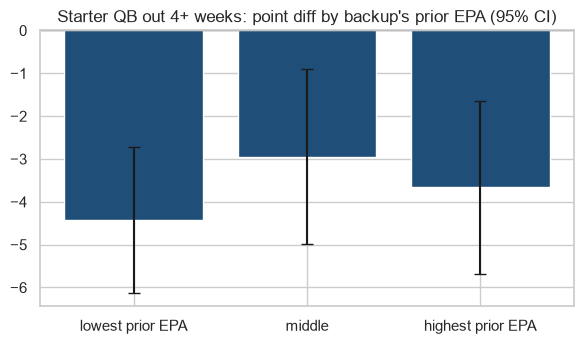

starter-out seasons only, n=76:
                                            coef     p
cap hit ($M)  [section 10]                 0.055 0.845
prior EPA/100 plays                        0.043 0.751
experience (000s of pass plays)           -0.791 0.006
draft pedigree (log pick; lower = better)  0.017 0.971


,n,prior_epa,experience_k,backup_cap_m,weeks_missed,pt_diff_pg,off_epa100,se
tier,,,,,,,,
lowest prior EPA,26,-3.950,1.270,2.820,8.080,-4.430,-6.010,0.870
middle,25,1.310,0.600,2.800,7.560,-2.940,-5.120,1.040
highest prior EPA,25,3.770,0.990,3.200,8.600,-3.670,-6.720,1.040


In [29]:
# the cleanest look again: only seasons where the starter was out 4+ weeks, backups split into thirds by PRIOR EPA
out = ins[ins.missed >= 4].copy()
out["tier"] = pd.qcut(out.q2_epa, 3, labels=["lowest prior EPA", "middle", "highest prior EPA"])
t = out.groupby("tier", observed=True).agg(n=("team", "size"), prior_epa=("q2_epa", "mean"), experience_k=("q2_exp", "mean"), backup_cap_m=("qb2_cap", "mean"),
        weeks_missed=("missed", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), sd=("pt_diff_pg", "std"), off_epa100=("off", "mean"))
t["se"] = t.sd / np.sqrt(t.n)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(t.index, t.pt_diff_pg, yerr=1.96 * t.se, capsize=4, color="#1f4e79"); ax.axhline(0, color="grey", lw=1)
ax.set(title="Starter QB out 4+ weeks: point diff by backup's prior EPA (95% CI)"); plt.tight_layout(); plt.show()
# exploratory: within the starter-out seasons, does any measure line up with results? (4 tests, so treat a lone small p cautiously)
ex = pd.DataFrame({lab: {"coef": fit(f"pt_diff_pg ~ {v} + qb1_cap", out).params[v], "p": fit(f"pt_diff_pg ~ {v} + qb1_cap", out).pvalues[v]} for v, lab, _ in MEASURES}).T
print(f"starter-out seasons only, n={len(out)}:"); print(ex.round(3))
t.drop(columns="sd").round(2)

## 12. The replacement QB who actually played

Sections 10 and 11 used the *planned* backup (second-highest cap). That is often not who plays. Here I identify the **actual main replacement**: the non-starter QB who threw the most passes for the team that season. His quality is still measured **before** the season, so who played cannot leak the outcome into the quality measure.

**Who plays.** In the 76 seasons where the starter was out 4+ weeks, the planned backup was the main replacement only **53%** of the time. The rest were a third-stringer or an in-season signing. Replacements threw 59% of the team's passes on average. This also means the planned-backup tests in sections 10 and 11 measured the right QB only about half the time, which would blur any true effect.

**Prior quality predicts how replacements play, with a caveat.** Across 124 main replacements with 100+ pass plays, prior EPA predicts actual EPA with a slope of 0.89 (correlation 0.28, lower than before because replacements are a narrow, noisy group). But they play far *below* their prior on average (-7.8 vs. +0.2 EPA/100). The vertical stack of dots in the left chart is unknown QBs shrunk to the league-average prior, who then play well below it. That is a level problem (typical backups are below average), not a slope problem, and the insurance test depends only on the slope.

**What a better replacement should be worth, against what we measure.** One standard deviation of replacement quality is 4.7 EPA/100. Multiply by the validated slope (0.89) and by the share of passes a replacement throws when the starter is out 6-10 weeks (57%) and a working insurance policy should add about **+2.4 passing EPA/100**. Eight missed weeks cost about 11, so even a *real* effect recovers only **about a fifth** of the damage.

| Outcome | +1 SD better replacement, starter out 8 weeks | 95% interval | Share of damage | p |
|---|---|---|---|---|
| Team passing EPA/100 | +2.2 | -0.4 to +4.8 | 20% (-4% to 44%) | 0.15 |
| Point differential | +0.2 pts/game | -0.9 to +1.3 | 4% (-18% to 26%) | 0.97 |

**Reading it.** The measured passing effect (+2.2) is almost exactly what the mechanics predict (+2.4), but it is too imprecise to separate from zero with about 76 starter-out seasons. So \"no detectable cushion\" (sections 10-11) and \"a small cushion of about a fifth per standard deviation\" are the **same finding**: the data cannot rule out the small effect theory predicts. They also cannot rule out a benefit several times that size: per standard deviation, the upper ends of the intervals are about 44% of the passing-EPA damage and 26% of the point-differential damage. The honest summary is \"probably small, not precisely known\".

*Limits:* the validated slope comes from the same replacement sample, so the match is not fully independent evidence; who replaces the starter is chosen after the injury; the prior is shrunk toward league average rather than replacement level (section 13 recalibrates this and reaches the same conclusion); and a star-level backup (well beyond one standard deviation) is too rare to test.

In [30]:
# Sections 10-11 used the PLANNED backup (second-highest cap). The QB who actually replaces an injured starter is often someone else.
# Here: the actual main replacement = the non-starter QB who threw the most passes for the team that season; his quality is still measured
# BEFORE the season (prior EPA, section 11), so who-played does not leak outcomes into the quality measure.
qt = pd.read_parquet("data/qb_team_season.parquet")
rep_rows = []
for r in ins.itertuples():
    tq = qt[(qt.team == r.team) & (qt.season == r.season)]
    q1 = tq[tq.gsis_id == r.qb1_gsis]
    others = tq[tq.gsis_id != r.qb1_gsis].sort_values("pass_plays", ascending=False)
    row = {"rep_share": 1 - q1.pass_plays.sum() / tq.pass_plays.sum()}
    if len(others):
        m = others.iloc[0]
        row.update({"rep_gsis": m.gsis_id, "rep_plays": m.pass_plays, "rep_epa": m.epa_sum / m.pass_plays * 100,
                    "rep_prior": prior_epa(m.gsis_id, r.season)[0], "rep_is_planned": m.gsis_id == r.qb2_gsis})
    else:
        row.update({"rep_prior": prior_epa("none", r.season)[0], "rep_is_planned": False})
    rep_rows.append(row)
ins = pd.concat([ins.drop(columns=[c for c in ["rep_share", "rep_gsis", "rep_plays", "rep_epa", "rep_prior", "rep_is_planned"] if c in ins.columns]).reset_index(drop=True),
                 pd.DataFrame(rep_rows)], axis=1)

out = ins[ins.missed >= 4]
print(f"starter out 4+ weeks: {len(out)} seasons")
print(f"  the PLANNED backup was the main replacement in {out.rep_is_planned.mean():.0%} of them (otherwise a third-stringer or an in-season signing)")
print(f"  replacements threw {out.rep_share.mean():.0%} of the team's passes on average (median {out.rep_share.median():.0%})")

# does the pre-season quality measure predict how the ACTUAL replacement played? (replacements with 100+ pass plays)
v = ins.dropna(subset=["rep_epa"]); v = v[v.rep_plays >= 100]
slope = np.polyfit(v.rep_prior, v.rep_epa, 1)[0]
print(f"\nactual replacements with 100+ pass plays (n={len(v)}): corr(prior EPA, actual EPA) = {v.rep_prior.corr(v.rep_epa):.2f}, slope {slope:.2f}")
print(f"  mean prior {v.rep_prior.mean():+.1f} vs mean actual {v.rep_epa.mean():+.1f} EPA/100 pass plays: they play BELOW their prior on average,")
print("  because unknown QBs are shrunk toward the league average and typical backups are below average (a level problem, not a slope problem)")
v[["rep_prior", "rep_epa", "rep_plays"]].describe().round(1).T

starter out 4+ weeks: 76 seasons
  the PLANNED backup was the main replacement in 53% of them (otherwise a third-stringer or an in-season signing)
  replacements threw 59% of the team's passes on average (median 55%)

actual replacements with 100+ pass plays (n=124): corr(prior EPA, actual EPA) = 0.28, slope 0.89
  mean prior +0.2 vs mean actual -7.8 EPA/100 pass plays: they play BELOW their prior on average,
  because unknown QBs are shrunk toward the league average and typical backups are below average (a level problem, not a slope problem)


,count,mean,std,min,25%,50%,75%,max
rep_prior,124.000,0.200,4.500,-17.200,-2.300,2.000,2.600,17.500
rep_epa,124.000,-7.800,14.100,-46.600,-15.900,-7.500,0.800,29.700
rep_plays,124.000,290.600,142.800,102.000,170.500,262.000,374.200,679.000


spread of replacement quality: 1 SD = 4.7 EPA/100;  replacement throws 57% of passes when the starter is out 6-10 weeks
expected effect = validated slope 0.89 x 4.7 x 0.57 = +2.38 passing EPA/100  (22% of the damage)


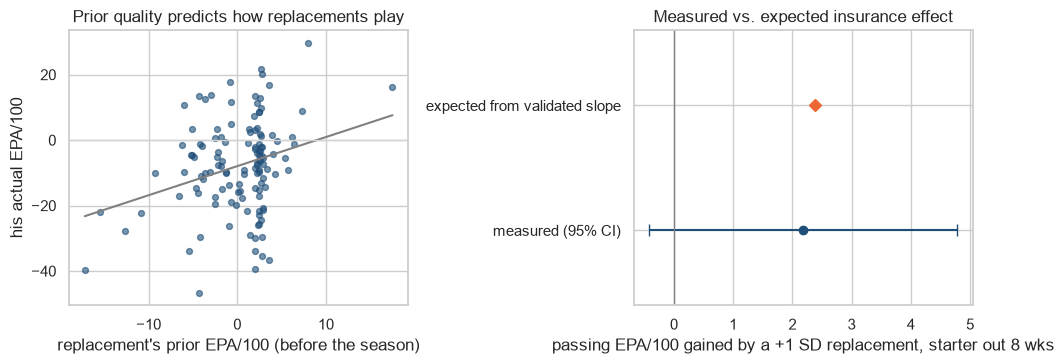

,team passing EPA/100,point diff/game
+1 SD better replacement,2.180,0.200
ci low,-0.410,-0.880
ci high,4.780,1.280
damage of 8 missed wks,-10.990,-4.940
as % of damage,19.870,4.080
pct low,-3.770,-17.790
pct high,43.510,25.950
interaction p,0.150,0.970
expected if quality works as validated,2.380,NaN


In [31]:
# measured effect of a better ACTUAL replacement vs. what the validated slope predicts it should be
# outcome: team passing offense EPA per 100 pass plays (same units as the validation slope), plus point differential
ins = ins.merge(ts[["season", "team", "off_pass_epa_play"]].assign(off_pass100=lambda x: x.off_pass_epa_play * 100).drop(columns="off_pass_epa_play"), on=["season", "team"])
sd = ins.rep_prior.std()
band = ins[(ins.missed >= 6) & (ins.missed <= 10)]
exposure = band.rep_share.mean()
def effect_8wk(y):
    m = fit(f"{y} ~ missed * rep_prior + qb1_cap", ins)
    w = pd.Series(0.0, index=m.params.index); w["rep_prior"] = sd; w["missed:rep_prior"] = 8 * sd     # +1 SD better replacement, starter out 8 weeks
    est, se = (w * m.params).sum(), np.sqrt(w.values @ m.cov_params().values @ w.values)
    return est, est - 1.96 * se, est + 1.96 * se, 8 * m.params["missed"], m.pvalues["missed:rep_prior"]
res = {}
for y, lab in [("off_pass100", "team passing EPA/100"), ("pt_diff_pg", "point diff/game")]:
    est, lo, hi, dmg, p = effect_8wk(y); res[lab] = {"+1 SD better replacement": est, "ci low": lo, "ci high": hi, "damage of 8 missed wks": dmg,
                                                    "as % of damage": 100 * est / -dmg, "pct low": 100 * lo / -dmg, "pct high": 100 * hi / -dmg, "interaction p": p}
expected = slope * sd * exposure
res["team passing EPA/100"]["expected if quality works as validated"] = expected
print(f"spread of replacement quality: 1 SD = {sd:.1f} EPA/100;  replacement throws {exposure:.0%} of passes when the starter is out 6-10 weeks")
print(f"expected effect = validated slope {slope:.2f} x {sd:.1f} x {exposure:.2f} = {expected:+.2f} passing EPA/100  "
      f"({100 * expected / -res['team passing EPA/100']['damage of 8 missed wks']:.0f}% of the damage)")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(v.rep_prior, v.rep_epa, s=18, alpha=.6, color="#1f4e79"); xs = np.array([v.rep_prior.min(), v.rep_prior.max()])
axes[0].plot(xs, np.polyval(np.polyfit(v.rep_prior, v.rep_epa, 1), xs), color="grey"); axes[0].axhline(0, color="lightgrey", lw=1)
axes[0].set(xlabel="replacement's prior EPA/100 (before the season)", ylabel="his actual EPA/100", title="Prior quality predicts how replacements play")
r = res["team passing EPA/100"]
axes[1].errorbar([r["+1 SD better replacement"]], [0], xerr=[[r["+1 SD better replacement"] - r["ci low"]], [r["ci high"] - r["+1 SD better replacement"]]], fmt="o", color="#1f4e79", capsize=4)
axes[1].plot([expected], [1], "D", color="#eb6834"); axes[1].axvline(0, color="grey", lw=1)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["measured (95% CI)", "expected from validated slope"]); axes[1].set_ylim(-.6, 1.6)
axes[1].set(xlabel="passing EPA/100 gained by a +1 SD replacement, starter out 8 wks", title="Measured vs. expected insurance effect")
plt.tight_layout(); plt.show()
pd.DataFrame(res).round(2)

## 13. Calibrating the QB prior to replacement level

**The problem.** Section 12 found replacement QBs play about 8 EPA/100 *below* their prior. The cause: a QB with little history was shrunk toward one league-wide average, and that average is dominated by starters. Real backups sit well below it.

**The fix.** Shrink each QB toward a target that depends on how much he has already played. QBs who keep getting snaps are better (survivorship), so the target for a QB with no history is **-5.3 EPA/100**, versus **+5.8** for one with 2,000 prior pass plays. The target is fit only on earlier seasons, so nothing leaks from the season being predicted. Draft pedigree added nothing once experience was included (I tested it), so it is left out.

**Calibration improves, though not fully.**
- Overall correlation with actual EPA rises from 0.43 to 0.50, and the slope goes from 0.98 to 1.00.
- For QBs with little history, the gap between prior and actual shrinks from 11 points (+1.6 vs. -9.5) to 5 points (-4.2 vs. -9.5).
- For established QBs the prior is slightly too optimistic (+4.6 vs. +2.5, a bit worse than before), and overall it still runs a few points high. A constant offset like that does not affect the insurance test, which depends on slope.

**Re-testing insurance with the calibrated prior** (+1 SD better QB, starter out 8 weeks):

| QB measured | Outcome | Old prior | Calibrated prior |
|---|---|---|---|
| Planned backup | Passing EPA/100 | -3.1 (p=0.08) | -1.0 (p=0.65) |
| Planned backup | Point diff | -0.3 | -0.4 |
| **Actual replacement** | Passing EPA/100 | +2.2 | **+1.9** (interval -0.5 to +4.2; 19% of damage) |
| **Actual replacement** | Point diff | +0.2 | **+0.5** (interval -0.3 to +1.2; 10% of damage) |

**What changed and what did not.**
- The odd *negative* result for planned backups (section 11) disappears once the prior is calibrated. It was a calibration artifact, not a real effect.
- The actual-replacement answer barely moves (19% of damage vs. 20%), so section 12's conclusion does not depend on how the prior is calibrated. The point-differential interval narrows (from -0.9 to +1.3 down to -0.3 to +1.2).
- The mechanical expectation with the calibrated slope (0.99) is +2.5 passing EPA/100, and the measured +1.9 is about three quarters of it, well inside the interval.
- Planned and actual now disagree in a sensible way: the planned backup shows nothing, the actual replacement shows a small positive effect. That fits the planned backup being the actual replacement only 53% of the time, so it is a noisy stand-in for the right QB.

**Bottom line.** A replacement QB one standard deviation better recovers roughly a tenth to a fifth of the damage from losing the starter, close to what the mechanics predict. The upper ends of the intervals are about 40% (passing EPA) and 26% (point differential), so \"small, not precisely known\" still stands.

*Limits:* the calibration is a simple two-parameter fit; the prior still runs high on average; and the sample is still about 76 starter-out seasons.

In [32]:
# Section 12 showed replacements play ~8 EPA/100 below their prior, because unknown QBs were shrunk toward the league average and that average is
# dominated by starters. Fix: shrink toward an expectation that depends on how much the QB has already played (survivors who keep getting snaps
# are better), estimated ONLY from earlier seasons so nothing leaks from the season being predicted.
qc = qs.sort_values(["gsis_id", "season"]).reset_index(drop=True).copy()
qc["epa100"] = qc.epa_sum / qc.pass_plays * 100
qc["n_prior"] = qc.groupby("gsis_id").pass_plays.cumsum() - qc.pass_plays          # career pass plays BEFORE this season
_mu = {}
def mu_params(season):
    if season not in _mu:
        h = qc[(qc.season < season) & (qc.season >= 2014) & (qc.pass_plays >= 100)]
        A = np.c_[np.ones(len(h)), np.log1p(h.n_prior / 100).to_numpy()]; w = np.sqrt(h.pass_plays.to_numpy())
        _mu[season] = np.linalg.lstsq(A * w[:, None], h.epa100.to_numpy() * w, rcond=None)[0]
    return _mu[season]
def calibrated_prior(gsis, season):
    h = qc[(qc.gsis_id == gsis) & (qc.season < season)]; n, e = h.pass_plays.sum(), h.epa_sum.sum()
    a, b = mu_params(season); target = (a + b * np.log1p(n / 100)) / 100
    return (e + K * target) / (n + K) * 100
a, b = mu_params(2025)
print(f"2025 shrink target: QB with no history {a:+.1f}, with 2,000 prior plays {a + b * np.log1p(20):+.1f} EPA/100 (the old target was one league-wide number)")

rows = []
for season in range(2016, 2026):
    for r in qc[(qc.season == season) & (qc.pass_plays >= 100)].itertuples():
        rows.append({"history": "little (<300 prior plays)" if r.n_prior < 300 else "real (300+)", "actual": r.epa100,
                     "old prior": prior_epa(r.gsis_id, season)[0], "calibrated prior": calibrated_prior(r.gsis_id, season)})
cal = pd.DataFrame(rows)
summ = {}
for grp, sub in [("all QB-seasons", cal)] + [(g, d) for g, d in cal.groupby("history")]:
    for p in ["old prior", "calibrated prior"]:
        summ[(grp, p)] = {"n": len(sub), "mean prior": sub[p].mean(), "mean actual": sub.actual.mean(), "corr": sub[p].corr(sub.actual), "slope": np.polyfit(sub[p], sub.actual, 1)[0]}
pd.DataFrame(summ).T.round(2)

2025 shrink target: QB with no history -5.3, with 2,000 prior plays +5.8 EPA/100 (the old target was one league-wide number)


n  mean prior  mean actual  \
all QB-seasons            old prior        443.000       3.350       -0.440   
                          calibrated prior 443.000       2.430       -0.440   
little (<300 prior plays) old prior        108.000       1.590       -9.470   
                          calibrated prior 108.000      -4.150       -9.470   
real (300+)               old prior        335.000       3.920        2.470   
                          calibrated prior 335.000       4.550        2.470   

                                            corr  slope  
all QB-seasons            old prior        0.430  0.980  
                          calibrated prior 0.500  1.000  
little (<300 prior plays) old prior        0.170  0.870  
                          calibrated prior 0.180  0.930  
real (300+)               old prior        0.490  0.890  
                          calibrated prior 0.480  0.870

calibrated prior among replacements with 100+ plays: slope 0.99, 1 SD = 4.4; mechanical expectation = 0.99 x 4.4 x 0.57 = +2.48 passing EPA/100


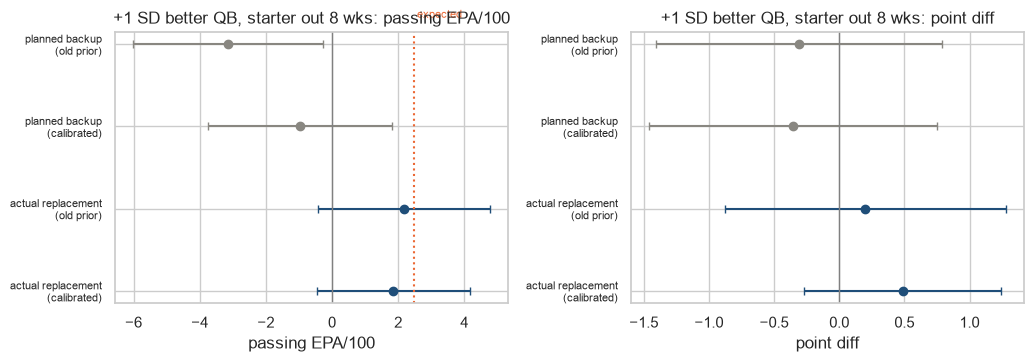

effect  ci low  ci high  \
planned backup     old prior  passing EPA/100  -3.140  -6.010   -0.260   
                              point diff       -0.310  -1.400    0.790   
                   calibrated passing EPA/100  -0.970  -3.750    1.820   
                              point diff       -0.360  -1.460    0.750   
actual replacement old prior  passing EPA/100   2.180  -0.410    4.780   
                              point diff        0.200  -0.880    1.280   
                   calibrated passing EPA/100   1.860  -0.460    4.180   
                              point diff        0.490  -0.270    1.240   

                                               % of damage  interaction p  
planned backup     old prior  passing EPA/100      -30.540          0.080  
                              point diff            -6.300          0.650  
                   calibrated passing EPA/100       -9.020          0.650  
                              point diff            -7.230          0.780  
actual replacement old prior  passing EPA/100       19.870          0.150  
                              point diff             4.080          0.970  
                   calibrated passing EPA/100       18.910          0.200  
                              point diff            10.150          0.600

In [33]:
# re-run the insurance tests (sections 11-12) with the calibrated prior, for the PLANNED backup and the ACTUAL replacement
ins["plan_cal"] = [calibrated_prior(g if g is not None else "none", s) for g, s in zip(ins.qb2_gsis, ins.season)]
ins["rep_cal"] = [calibrated_prior(g if isinstance(g, str) else "none", s) for g, s in zip(ins.rep_gsis, ins.season)]
rv = ins.dropna(subset=["rep_epa"]); rv = rv[rv.rep_plays >= 100]
slope_cal = np.polyfit(rv.rep_cal, rv.rep_epa, 1)[0]

def eff(var, y):
    sd = ins[var].std(); m = fit(f"{y} ~ missed * {var} + qb1_cap", ins)
    w = pd.Series(0.0, index=m.params.index); w[var] = sd; w[f"missed:{var}"] = 8 * sd           # +1 SD better, starter out 8 weeks
    est, se = (w * m.params).sum(), np.sqrt(w.values @ m.cov_params().values @ w.values); dmg = 8 * m.params["missed"]
    return {"effect": est, "ci low": est - 1.96 * se, "ci high": est + 1.96 * se, "% of damage": 100 * est / -dmg, "interaction p": m.pvalues[f"missed:{var}"]}
CASES = [("planned backup", "old prior", "q2_epa"), ("planned backup", "calibrated", "plan_cal"), ("actual replacement", "old prior", "rep_prior"), ("actual replacement", "calibrated", "rep_cal")]
tab = {}
for who, which, var in CASES:
    for y, lab in [("off_pass100", "passing EPA/100"), ("pt_diff_pg", "point diff")]:
        tab[(who, which, lab)] = eff(var, y)
tab = pd.DataFrame(tab).T
sd_cal = ins.rep_cal.std(); exposure = ins[(ins.missed >= 6) & (ins.missed <= 10)].rep_share.mean()
expected = slope_cal * sd_cal * exposure
print(f"calibrated prior among replacements with 100+ plays: slope {slope_cal:.2f}, 1 SD = {sd_cal:.1f}; mechanical expectation = {slope_cal:.2f} x {sd_cal:.1f} x {exposure:.2f} = {expected:+.2f} passing EPA/100")
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, lab in zip(axes, ["passing EPA/100", "point diff"]):
    sub = tab.xs(lab, level=2)
    for i, ((who, which), r) in enumerate(sub.iterrows()):
        ax.errorbar(r["effect"], i, xerr=[[r["effect"] - r["ci low"]], [r["ci high"] - r["effect"]]], fmt="o", capsize=3, color="#1f4e79" if who == "actual replacement" else "#898781")
    ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(4)); ax.set_yticklabels([f"{w}\n({c})" for (w, c) in sub.index], fontsize=8); ax.invert_yaxis()
    ax.set(title=f"+1 SD better QB, starter out 8 wks: {lab}", xlabel=lab)
axes[0].axvline(expected, color="#eb6834", lw=1.5, ls=":"); axes[0].text(expected, -0.42, " expected", color="#eb6834", fontsize=8, va="top")
plt.tight_layout(); plt.show()
tab.round(2)

## 14. Do QB returns flatten at the top?

Section 4b hinted that veteran QBs peak near $20M and dip above about $25M, but the gap was only about 2 standard errors. This section tests it properly.

**Dollars are the wrong yardstick, so I use share of cap.** Only 45 team-seasons have a $25M+ starting QB, all since 2018 and 21 of them in 2024-25. And $25M was 23% of the average team's tracked cap in 2013 but only 11% in 2025. A dollar cutoff would mostly compare eras.

**Yes, returns diminish.** Raw point differential climbs through the middle tiers, peaks at 12-15% of cap (+2.8), then falls to +0.8 in the 15%+ tier (59 team-seasons). The formal checks agree:
- **The pre-planned test.** Adding a squared term gives a significantly negative coefficient on point differential (p=0.005, and p=0.024 with the other positions held fixed), with a turning point at about **14-16% of tracked cap** (roughly $31-36M at 2025's average). Among veteran-deal QBs alone it is stronger (p=0.001).
- **The curve.** A flexible spline (the best fit by AIC, though only modestly) peaks near 14% of cap at about +5.6 pts/game and eases to +2.4 at 21%.
- **The literal $25M version.** The payoff is about +0.25 pts/game per $M below $25M and roughly flat (-0.08) above it (the slope change has p=0.003, with only 41 team-seasons above).
- **Offense EPA** shows the same shape more weakly (squared term p=0.04 to 0.13) with a later turning point (19-22% of cap, near the edge of the data), so there the story is diminishing returns more than a decline.

**But \"turns negative\" is not established.** Three things keep this honest:
- The slope *change* above a knot is significant for knots from 10% to 16% of cap, but the slope *above* the knot is imprecise and its interval includes zero at every knot from 12% up. (Scanning many knots flatters the best one, so treat the scan as a picture of where the slope turns down, not a second test.)
- In the spline bootstrap (resampling whole teams), the drop from peak to the top of the range is positive in 96% of resamples, but its 95% interval runs from -0.3 to +7.7, so it just includes zero.
- The 15%+ tier has only 59 team-seasons from 27 QBs.

**Who is up there.** The top tier mixes superstar seasons (Stafford 2025 at +10.1, Brees 2018, Allen 2024, Mahomes 2022) with big misses (Geno Smith 2025 at -11.2, Carr 2018, Kaepernick 2016). The spread is about the same as in the 12-15% tier (SD about 5), but 22% of top-tier seasons were below -3 versus 12% in the 12-15% tier. That is consistent with both stars and costly mistakes getting paid at the top, which the data cannot separate.

**Bottom line.** Spending on a QB keeps paying off up to roughly 14% of the cap and then tapers, with a likely but unproven decline beyond that. Cap hit is an accounting number (restructures and late-contract spikes inflate it), so this says something about the *price tag*, not necessarily about the player.

*Limits:* 59 team-seasons at the top; contract timing and restructures; teams may pay for past performance that regresses; the same QB appears in several seasons (handled by clustering and resampling teams, not players).

In [34]:
# Section 4b hinted that veteran QBs peak near $20M and dip above ~$25M. A dollar cutoff is the wrong yardstick: the cap grew from ~$123M to ~$280M,
# so $25M meant a very different thing in 2013 and 2025. The test below uses the QB's share of tracked cap.
over25 = ts[ts.QB_starter >= 25]
print(f"{len(over25)} team-seasons have a starting QB with a cap hit of $25M+: all in {over25.season.min()}-{over25.season.max()}, and {(over25.season >= 2024).sum()} are from 2024-25")
print("what $25M is as a share of the average team's tracked cap:", {y: f"{25 / ts[ts.season == y].tracked_cap_m.mean() * 100:.0f}%" for y in [2013, 2018, 2025]})
b = ts.assign(tier=pd.cut(ts.QB_st, [0, 6, 9, 12, 15, 30], labels=["<6%", "6-9%", "9-12%", "12-15%", "15%+"]))
b.groupby("tier", observed=True).agg(n=("team", "size"), avg_qb_cap_m=("QB_starter", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), sd=("pt_diff_pg", "std"),
    share_below_minus3=("pt_diff_pg", lambda x: (x < -3).mean()), share_above_plus4=("pt_diff_pg", lambda x: (x > 4).mean())).round(2)

45 team-seasons have a starting QB with a cap hit of $25M+: all in 2018-2025, and 21 are from 2024-25
what $25M is as a share of the average team's tracked cap: {2013: '23%', 2018: '16%', 2025: '11%'}


,n,avg_qb_cap_m,pt_diff_pg,sd,share_below_minus3,share_above_plus4
tier,,,,,,
<6%,221,4.580,-1.350,6.100,0.410,0.200
6-9%,30,11.640,0.900,6.730,0.330,0.330
9-12%,48,18.000,1.220,6.010,0.290,0.330
12-15%,58,20.380,2.840,5.220,0.120,0.380
15%+,59,28.670,0.840,5.160,0.220,0.320


In [35]:
# the pre-specified test: add a squared term. A negative squared term means the payoff per extra dollar shrinks as the QB's share rises.
CTRL = " + ".join(f"{p}_st" for p in POS if p != "QB") + " + ST_pct"
ts["qb_sq"] = ts.QB_st ** 2 / 10
avg25 = ts[ts.season == 2025].tracked_cap_m.mean()
rows = []
for data, dlab in [(ts, "all QBs"), (ts[ts.rookie == 0], "veteran-deal QBs only")]:
    for y, ylab in [("pt_diff_pg", "point diff"), ("off", "offense EPA"), ("off_pass", "passing EPA")]:
        for spec, rhs in [("simple", "QB_st + qb_sq"), ("with controls", "QB_st + qb_sq + " + CTRL)]:
            if dlab != "all QBs" and (ylab != "point diff" or spec != "simple"): continue
            m = fit(f"{y} ~ {rhs}", data); b1, b2 = m.params["QB_st"], m.params["qb_sq"]
            turn = -b1 / (2 * b2 / 10) if b2 < 0 else np.nan
            rows.append({"sample": dlab, "outcome": ylab, "model": spec, "linear": b1, "squared (x10)": b2, "p (squared)": m.pvalues["qb_sq"],
                         "turning point (% of cap)": turn, "= $M at 2025 avg cap": turn / 100 * avg25})
curv = pd.DataFrame(rows).set_index(["sample", "outcome", "model"])
aic = {lab: smf.ols(f"pt_diff_pg ~ {rhs} + {CTRL} + C(season)", ts).fit().aic for lab, rhs in
       [("linear", "QB_st"), ("quadratic", "QB_st + qb_sq"), ("cubic", "QB_st + qb_sq + I(QB_st**3/100)"), ("spline (4 df)", "cr(QB_st, df=4, constraints='center')")]}
print("AIC (lower is better), point diff with controls:", {k: round(v, 1) for k, v in aic.items()})
curv.round(3)

AIC (lower is better), point diff with controls: {'linear': np.float64(2684.0), 'quadratic': np.float64(2680.6), 'cubic': np.float64(2680.4), 'spline (4 df)': np.float64(2679.6)}


linear  squared (x10)  \
sample                outcome     model                                  
all QBs               point diff  simple          0.718         -0.264   
                                  with controls   0.716         -0.227   
                      offense EPA simple          0.879         -0.228   
                                  with controls   0.880         -0.197   
                      passing EPA simple          1.379         -0.365   
                                  with controls   1.367         -0.319   
veteran-deal QBs only point diff  simple          1.079         -0.418   

                                                 p (squared)  \
sample                outcome     model                        
all QBs               point diff  simple               0.005   
                                  with controls        0.024   
                      offense EPA simple               0.082   
                                  with controls        0.128   
                      passing EPA simple               0.038   
                                  with controls        0.073   
veteran-deal QBs only point diff  simple               0.001   

                                                 turning point (% of cap)  \
sample                outcome     model                                     
all QBs               point diff  simple                           13.586   
                                  with controls                    15.774   
                      offense EPA simple                           19.254   
                                  with controls                    22.355   
                      passing EPA simple                           18.881   
                                  with controls                    21.391   
veteran-deal QBs only point diff  simple                           12.902   

                                                 = $M at 2025 avg cap  
sample                outcome     model                                
all QBs               point diff  simple                       30.963  
                                  with controls                35.949  
                      offense EPA simple                       43.880  
                                  with controls                50.947  
                      passing EPA simple                       43.031  
                                  with controls                48.751  
veteran-deal QBs only point diff  simple                       29.405

literal $25M hinge: slope below +0.25 pts/g per $M, change above -0.33 (p=0.003); only 41 team-seasons are above $25M


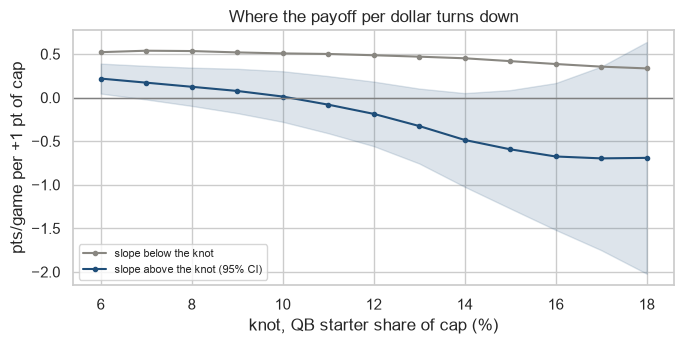

,team-seasons above,slope below,slope above,lo,hi,p (change)
knot (% of cap),,,,,,
6,195,0.520,0.220,0.050,0.390,0.210
7,183,0.540,0.170,-0.020,0.360,0.120
8,174,0.530,0.120,-0.100,0.340,0.080
9,165,0.520,0.080,-0.180,0.330,0.070
10,147,0.510,0.010,-0.280,0.300,0.050
11,134,0.500,-0.080,-0.410,0.250,0.020
12,117,0.490,-0.190,-0.560,0.180,0.010
13,93,0.470,-0.330,-0.760,0.100,0.000
14,74,0.450,-0.490,-1.020,0.050,0.000


In [36]:
# the "knee" version: how does the slope change above a given share? Scanning several knots flatters the best one, so this is a picture of
# where the slope turns down, not a separate test (the squared term above is the single pre-planned test).
scan = []
for k in range(6, 19):
    ts["hinge"] = np.maximum(ts.QB_st - k, 0); m = fit("pt_diff_pg ~ QB_st + hinge + " + CTRL)
    w = np.array([1.0 if n in ("QB_st", "hinge") else 0.0 for n in m.params.index]); est = (w * m.params.values).sum(); se = np.sqrt(w @ m.cov_params().values @ w)
    scan.append({"knot (% of cap)": k, "team-seasons above": int((ts.QB_st > k).sum()), "slope below": m.params["QB_st"], "slope above": est,
                 "lo": est - 1.96 * se, "hi": est + 1.96 * se, "p (change)": m.pvalues["hinge"]})
scan = pd.DataFrame(scan).set_index("knot (% of cap)")
ts["hinge_m"] = np.maximum(ts.QB_starter - 25, 0); mm = fit("pt_diff_pg ~ QB_starter + hinge_m + " + CTRL)
print(f"literal $25M hinge: slope below {mm.params['QB_starter']:+.2f} pts/g per $M, change above {mm.params['hinge_m']:+.2f} (p={mm.pvalues['hinge_m']:.3f}); only {(ts.QB_starter > 25).sum()} team-seasons are above $25M")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(scan.index, scan["slope below"], color="#898781", marker="o", ms=3, label="slope below the knot")
ax.fill_between(scan.index, scan.lo, scan.hi, color="#1f4e79", alpha=.15); ax.plot(scan.index, scan["slope above"], color="#1f4e79", marker="o", ms=3, label="slope above the knot (95% CI)")
ax.axhline(0, color="grey", lw=1); ax.set(xlabel="knot, QB starter share of cap (%)", ylabel="pts/game per +1 pt of cap", title="Where the payoff per dollar turns down"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
scan.round(2)

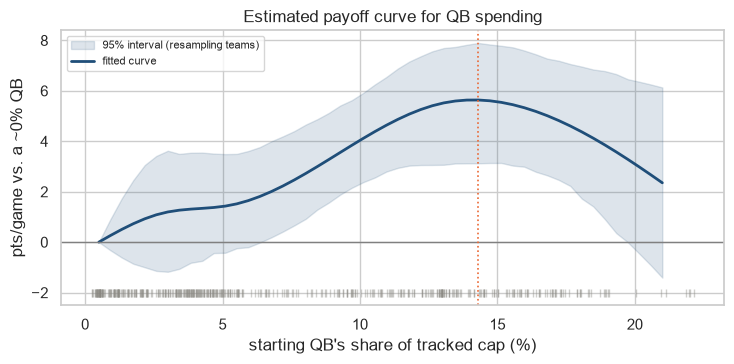

fitted curve peaks near 14.3% of cap (+5.6 pts/g); at 21% it is +2.4, a drop of 3.3 from the peak
bootstrap: peak-to-top drop is positive in 96% of resamples (95% interval -0.3 to 7.7)

15%+ tier: 59 team-seasons, 27 different QBs, mean +0.8, 42% below zero


,player,season,team,cap_m,QB_st,pt_diff_pg
group,,,,,,
best,Matt Stafford,2025,LA,47.500,22.100,10.100
best,Drew Brees,2018,NO,24.000,15.600,9.400
best,Josh Allen,2024,BUF,30.400,16.700,9.200
best,Matt Ryan,2016,ATL,23.800,18.300,8.400
best,Patrick Mahomes,2022,KC,35.800,18.900,7.500
worst,Geno Smith,2025,LV,40.000,18.700,-11.200
worst,Derek Carr,2018,LV,25.000,16.400,-11.100
worst,Colin Kaepernick,2016,SF,20.200,16.100,-10.700
worst,Matt Ryan,2021,ATL,26.900,17.400,-8.600


In [37]:
# the shape itself: a spline (flexible curve) with a cluster-bootstrap interval (resample whole teams), other positions held at their averages
FORM = "pt_diff_pg ~ cr(QB_st, df=4, constraints='center') + " + CTRL + " + C(season)"
grid = np.linspace(0.5, 21, 50); others = [c for c in CTRL.replace(" + ", " ").split()]
def curve(data):
    m = smf.ols(FORM, data).fit(); nd = pd.DataFrame({"QB_st": grid, **{c: data[c].mean() for c in others}, "season": 2019})
    y = m.predict(nd).to_numpy(); return y - y[0]                       # effect relative to a QB at 0.5% of cap
fitted = curve(ts); rng = np.random.default_rng(0); teams = ts.team.unique(); boots = []
for _ in range(400):
    pick = rng.choice(teams, len(teams), replace=True); boots.append(curve(pd.concat([ts[ts.team == t] for t in pick])))
lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
peak = grid[fitted.argmax()]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.fill_between(grid, lo, hi, color="#1f4e79", alpha=.15, label="95% interval (resampling teams)"); ax.plot(grid, fitted, color="#1f4e79", lw=2, label="fitted curve")
ax.plot(ts.QB_st, np.full(len(ts), lo.min() - 0.6), "|", color="#898781", alpha=.4, ms=6)
ax.axhline(0, color="grey", lw=1); ax.axvline(peak, color="#eb6834", lw=1.2, ls=":")
ax.set(xlabel="starting QB's share of tracked cap (%)", ylabel="pts/game vs. a ~0% QB", title="Estimated payoff curve for QB spending"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
i_peak, i_end = fitted.argmax(), -1
print(f"fitted curve peaks near {peak:.1f}% of cap ({fitted[i_peak]:+.1f} pts/g); at {grid[-1]:.0f}% it is {fitted[i_end]:+.1f}, a drop of {fitted[i_peak] - fitted[i_end]:.1f} from the peak")
drop = np.array([bb[i_peak] - bb[i_end] for bb in boots]); print(f"bootstrap: peak-to-top drop is positive in {(drop > 0).mean():.0%} of resamples (95% interval {np.percentile(drop, 2.5):.1f} to {np.percentile(drop, 97.5):.1f})")

# who is in the 15%+ tier?
names = ps[(ps.pos_group == "QB") & (ps.role == "starter")][["season", "team", "player", "cap_m"]]
tier = ts.merge(names, on=["season", "team"]); tier = tier[tier.QB_st >= 15]
print(f"\n15%+ tier: {len(tier)} team-seasons, {tier.player.nunique()} different QBs, mean {tier.pt_diff_pg.mean():+.1f}, {(tier.pt_diff_pg < 0).mean():.0%} below zero")
show = pd.concat([tier.nlargest(5, "pt_diff_pg").assign(group="best"), tier.nsmallest(5, "pt_diff_pg").assign(group="worst")])
show[["group", "player", "season", "team", "cap_m", "QB_st", "pt_diff_pg"]].round(1).set_index("group")

## 15. A third outcome: overall finish

**What it is.** Overall finish is where a team ended the season among the 32 teams, from 1 (champion) to 32 (worst). It is read from the league's own ordering of the next first-round draft: each team's **original, pre-trade slot** (slot 1 = worst finish ... slot 32 = champion), flipped so that 1 is best. The league's rule puts non-playoff teams first by reverse record, then playoff teams by the round they lost in, with the champion last. So unlike point differential, finish includes playoff results.

**How I got the slot, and how sure I am.** I can't just read the real draft: picks get traded (at least 131 of the 416 slots changed hands in these drafts) and two drafts lost a first-rounder to a forfeit. So I rebuilt each team's original slot from the standings using the league's rule, splitting equal records by strength of schedule (the team with the *lower* strength of schedule picks first). I then compared the result with the real drafts and the trades table:

| Check | Slots |
|---|---|
| The team used its own pick | 257 |
| Traded, confirmed in the trades table | 131 |
| Forfeited first-rounder (excluded) | 2 |
| Not verifiable | 26 |

That is **93% verified (388 of 416)**. The 26 that cannot be verified are mostly exact ties in record *and* schedule strength, which the league settles with rules or coin flips I cannot see, and recent trades missing from the table (16 of the 26 are in the 2026 draft). Where the real draft shows exactly the tied teams holding exactly their slots, I used the real order. Two sanity checks: the team ranked 1 each year is that year's actual champion, and finish correlates -0.96 with win % and -0.88 with point differential (negative only because 1 = best).

**Results.** Coefficients are flipped to *places gained* per point of cap share, so positive means a better finish, matching the other outcomes.
- **QB: +0.44 places** (95% interval 0.29 to 0.60, p<0.001), significant under all 6 starter definitions. One standard deviation more starter-QB spending (5.8 points) is worth about 2.6 places.
- **OL +0.27** (p=0.009, 6 of 6) and **EDGE +0.33** (p=0.016, 5 of 6).
- **WR +0.20** (p=0.044, 6 of 6) clears the 5% line here, where it narrowly missed on point differential (p=0.063). That fits section 7, where WR showed a real offensive-EPA effect.
- **CB +0.19** (p=0.11, 3 of 6) is weaker than on point differential (p=0.024).
- **TE +0.71** (p=0.004, 6 of 6) is again the largest estimate, and again the position that fails the offense-versus-defense placebo test in section 7, so the same caution applies.
- RB, LB, DL and S show no detectable effect. The model explains about 10% of finish, the same as for point differential.

**What the outcome adds.** Mostly agreement: the ranking of reliable positions is the same, with QB first. Finish is a blunter measure (a rank, and it carries playoff luck), but it is the league's own record of how the season ended, and it is what draft position depends on.

*Limits:* the slot is reconstructed, not observed (a few exact-tie teams may be off by a place); and because finish is a rank within each season, the season fixed effects are harmless but do no work here.

In [38]:
# Overall finish = where the team ended up in the standings, read off the league's own ordering of the next first-round draft:
# each team's ORIGINAL (pre-trade) first-round slot. Slot 1 = worst finish ... slot 32 = champion; finish = 33 - slot, so 1 = best.
# The slot comes from the league rule (non-playoff teams by record, then playoff teams by the round they lost in, champion last),
# so it includes playoff results. Check it against what really happened in the drafts and the trades table.
import nflreadpy as nfl
from build_data import original_draft_order, resolve_exact_ties, DRAFT_CODE_FIX
sched = nfl.load_schedules(list(range(2013, 2026))).to_pandas()
picks = nfl.load_draft_picks(list(range(2014, 2027))).to_pandas(); picks = picks[picks["round"] == 1].copy(); picks["team"] = picks.team.replace(DRAFT_CODE_FIX)
trades = nfl.load_trades().to_pandas(); trades = trades[(trades.pick_round == 1) & trades.pick_season.between(2014, 2026)].copy()
for c in ("gave", "received"): trades[c] = trades[c].replace(DRAFT_CODE_FIX)
counts = {"own pick used": 0, "traded (confirmed in the trades table)": 0, "forfeited first-rounder (excluded)": 0, "not verifiable": 0}; unver = []
for season in range(2013, 2026):
    draft, order = season + 1, original_draft_order(sched, season)
    a = picks[picks.season == draft].sort_values("pick"); seq, by_slot = a.team.tolist(), dict(zip(a.pick, a.team))
    if len(a) == 32: order = resolve_exact_ties(order, by_slot)
    pred = order.team.tolist(); gaves = trades[trades.pick_season == draft].groupby("pick_number").gave.apply(set).to_dict(); forfeited = None
    if len(seq) == 31:    # a forfeited first-rounder renumbers the real draft: drop the predicted team whose removal lines the two orders up best
        j = max(range(32), key=lambda i: sum(x == y for x, y in zip(seq, pred[:i] + pred[i + 1:]))); forfeited = pred[j]
    rest = [t for t in pred if t != forfeited]
    for slot, team in enumerate(pred, start=1):
        if team == forfeited: counts["forfeited first-rounder (excluded)"] += 1; continue
        k = rest.index(team) + 1 if forfeited else slot; actual = seq[k - 1] if forfeited else by_slot.get(slot)
        if actual == team: counts["own pick used"] += 1
        elif team in gaves.get(slot, set()) or team in gaves.get(k, set()): counts["traded (confirmed in the trades table)"] += 1
        else: counts["not verifiable"] += 1; unver.append(draft)
print(f"{sum(counts.values())} team-seasons:", counts)
print("slots verified against the real draft or trades table:", f"{(counts['own pick used'] + counts['traded (confirmed in the trades table)']) / 416:.0%}")
print("not verifiable, by draft year:", dict(pd.Series(unver).value_counts().sort_index()))
print(f"correlation of finish with win %: {ts.finish.corr(ts.win_pct):.2f}, with point differential: {ts.finish.corr(ts.pt_diff_pg):.2f}  (negative because 1 = best)")
ts.sort_values("finish").groupby("season").head(1)[["season", "team"]].set_index("season").T

416 team-seasons: {'own pick used': 257, 'traded (confirmed in the trades table)': 131, 'forfeited first-rounder (excluded)': 2, 'not verifiable': 26}
slots verified against the real draft or trades table: 93%
not verifiable, by draft year: {2015: np.int64(2), 2016: np.int64(1), 2017: np.int64(2), 2018: np.int64(4), 2025: np.int64(1), 2026: np.int64(16)}
correlation of finish with win %: -0.96, with point differential: -0.88  (negative because 1 = best)


season,2024,2013,2014,2016,2021,2023,2022,2015,2018,2019,2020,2017,2025
team,PHI,SEA,NE,NE,LA,KC,KC,DEN,NE,KC,TB,PHI,SEA


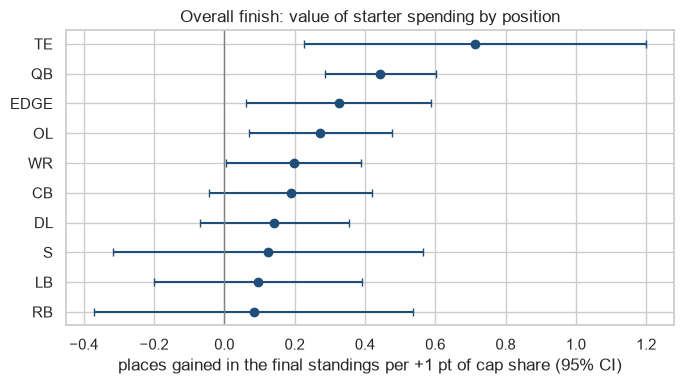

R-squared: finish 0.099, point differential 0.100.  1 SD of QB starter share = 5.8 pts -> about 2.6 places


,places gained per +1 pt,low,high,p,significant under (of 6),point-diff coef,point-diff p
TE,0.713,0.226,1.201,0.004,6,0.442,0.006
QB,0.444,0.287,0.602,0.000,6,0.307,0.000
EDGE,0.325,0.061,0.589,0.016,5,0.193,0.027
OL,0.273,0.069,0.477,0.009,6,0.152,0.026
WR,0.197,0.006,0.389,0.044,6,0.128,0.063
CB,0.189,-0.042,0.420,0.110,3,0.173,0.024
DL,0.142,-0.070,0.355,0.188,1,0.098,0.199
S,0.125,-0.316,0.566,0.579,0,0.092,0.533
LB,0.096,-0.200,0.392,0.524,0,0.133,0.243
RB,0.083,-0.371,0.538,0.719,0,0.219,0.167


In [39]:
# same joint model as sections 2 and 7, with overall finish as the outcome. Coefficients are flipped to PLACES GAINED so that
# positive = better, matching the other outcomes. Also: how many of the six starter definitions keep each result significant.
def finish_frame(rule):
    p = ps.copy(); p["role"] = assign_roles(p, rule)
    d = share_table(p).merge(ts[["season", "team", "finish", "pt_diff_pg"]], on=["season", "team"])
    for q in POS: d[f"{q}_st"] = d[f"{q}_starter_share"] * 100
    d["ST_pct"] = d.ST_all_share * 100
    return d
RHS = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"
base = finish_frame(STARTER_RULES["top-N (base 11)"]); mf = fit(f"finish ~ {RHS}", base); mpd = fit(f"pt_diff_pg ~ {RHS}", base)
k = {p: sum(finish_ols.pvalues[f"{p}_st"] < 0.05 for finish_ols in [fit(f"finish ~ {RHS}", finish_frame(r)) for r in STARTER_RULES.values()]) for p in POS}
ci = mf.conf_int()
res = pd.DataFrame({"places gained per +1 pt": [-mf.params[f"{p}_st"] for p in POS], "low": [-ci.loc[f"{p}_st", 1] for p in POS], "high": [-ci.loc[f"{p}_st", 0] for p in POS],
                    "p": [mf.pvalues[f"{p}_st"] for p in POS], "significant under (of 6)": [k[p] for p in POS],
                    "point-diff coef": [mpd.params[f"{p}_st"] for p in POS], "point-diff p": [mpd.pvalues[f"{p}_st"] for p in POS]}, index=POS).sort_values("places gained per +1 pt", ascending=False)
fig, ax = plt.subplots(figsize=(7, 4)); r = res.iloc[::-1]
ax.errorbar(r["places gained per +1 pt"], range(len(r)), xerr=[r["places gained per +1 pt"] - r.low, r.high - r["places gained per +1 pt"]], fmt="o", color="#1f4e79", capsize=3)
ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(r))); ax.set_yticklabels(r.index); ax.set(xlabel="places gained in the final standings per +1 pt of cap share (95% CI)", title="Overall finish: value of starter spending by position")
plt.tight_layout(); plt.show()
print(f"R-squared: finish {mf.rsquared:.3f}, point differential {mpd.rsquared:.3f}.  1 SD of QB starter share = {base.QB_st.std():.1f} pts -> about {-mf.params['QB_st'] * base.QB_st.std():.1f} places")
res.round(3)

## 16. A new row: dead money and unspent cap

**The problem.** The contract data has no dead cap: when a team releases a player, his leftover bonus is not in his season history (Russell Wilson's roughly $85M on Denver's 2024 books, for example, is missing). So "money not spent on active players" has to be recovered indirectly.

**The measure.** `dead_m` = the league's base salary cap that season minus every tracked cap hit. It is mostly dead money, but it also holds cap room a team simply left unused, and the two cannot be separated. Treat it as "cap not tied to a tracked player". Its average grew from about $16M a team in 2013 to about $51M in 2025, and the biggest team-seasons are the ones you would expect (Denver 2024, Atlanta and Chicago 2022). The base cap is typed in by hand (`BASE_CAP` in `build_data.py`) and does not include each team's carryover, which adds some noise. I express it as a share of tracked cap, like the positions, and compare it against bench money.

**Results.** Adding it to the joint model:
- It is negative and significant on every outcome: **-0.12 points per game**, **-0.11 offense EPA/100**, **-0.10 defense EPA/100** and **-0.17 places** in the final standings, for each extra point of cap share (p < 0.001 everywhere, and under all six starter definitions). One standard deviation (14.5 points) is worth about 1.7 points per game.
- It hurts offense and defense about equally, so it is not a position effect. It behaves like a team-wide signal.
- R-squared for point differential rises from 0.10 to 0.16.

**It changes the position results.** Dead money is partly standing in for team quality, so the position estimates shrink: QB goes from +0.31 to +0.26 points per game (still p < 0.001), and WR, OL, EDGE and CB move from borderline-significant to not significant on point differential (OL p = 0.026 to 0.063, EDGE 0.027 to 0.087, CB 0.024 to 0.078). The side-specific results (WR and OL on offense EPA, EDGE and CB on defense EPA) survive. Tight end is unchanged and still fails the placebo test.

**Do not read it as a cause.** Last season's dead money does not predict this season's results (p = 0.67); only the same season's does. That pattern fits dead money and unspent cap being a *consequence* of a bad year (teams that fall out of contention cut players and stop spending) as much as a cause, and it fits a roster that was already weak. It is a good marker of a struggling team, not evidence that dead money costs wins.

In [40]:
# Dead money is not in the contract data (a released player's leftover bonus is not in his season history), so recover it as a
# residual: the league's base cap minus every tracked cap hit (dead_m, built in build_data.py). It also contains any cap a team left
# unspent, and the two cannot be told apart. Shown as a share of tracked cap, compared against bench money like the positions.
ts["DEAD_pp"] = ts["dead_m"] / ts["tracked_cap_m"] * 100
print(ts.groupby("season")["dead_m"].mean().round(1).to_frame("avg $M").T.to_string())
print("\nlargest team-seasons ($M):"); print(ts.nlargest(6, "dead_m")[["season", "team", "dead_m", "tracked_cap_m"]].round(1).to_string(index=False))

RHS0 = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"
OUTS = {"point diff/game": "pt_diff_pg", "offense EPA/100": "off100", "defense EPA/100 (higher = better)": "def100", "finish (places gained)": "finish"}
ts["off100"] = ts.off_epa_play * 100; ts["def100"] = -ts.def_epa_play * 100
rows, cmp_ = [], {}
for lab, y in OUTS.items():
    m0, m1 = fit(f"{y} ~ {RHS0}"), fit(f"{y} ~ {RHS0} + DEAD_pp")
    s = -1 if y == "finish" else 1
    ci = m1.conf_int().loc["DEAD_pp"]
    rows.append({"outcome": lab, "dead $ effect per +1 pt": s * m1.params["DEAD_pp"], "low": min(s * ci[0], s * ci[1]), "high": max(s * ci[0], s * ci[1]),
                 "p": m1.pvalues["DEAD_pp"], "R2 without": m0.rsquared, "R2 with": m1.rsquared})
    cmp_[lab] = (m0, m1, s)
dead_tbl = pd.DataFrame(rows).set_index("outcome"); display(dead_tbl.round(3))

# does adding it change the positions? point differential, with and without
m0, m1, _ = cmp_["point diff/game"]
chg = pd.DataFrame({"without dead $": [m0.params[f"{p}_st"] for p in POS], "with dead $": [m1.params[f"{p}_st"] for p in POS],
                    "p without": [m0.pvalues[f"{p}_st"] for p in POS], "p with": [m1.pvalues[f"{p}_st"] for p in POS]}, index=POS)
display(chg.round(3))

# is it a one-year thing? last season's dead money against this season's results (teams in consecutive seasons)
ts = ts.sort_values(["team", "season"]); ts["DEAD_lag"] = ts.groupby("team")["DEAD_pp"].shift(1)
lag = ts.dropna(subset=["DEAD_lag"])
ml = fit(f"pt_diff_pg ~ {RHS0} + DEAD_pp + DEAD_lag", lag)
print(f"point diff: this season's dead $ {ml.params['DEAD_pp']:.3f} (p={ml.pvalues['DEAD_pp']:.4f}), last season's {ml.params['DEAD_lag']:.3f} (p={ml.pvalues['DEAD_lag']:.3f})")
print(f"1 SD of dead $ = {ts.DEAD_pp.std():.1f} pts -> about {m1.params['DEAD_pp'] * ts.DEAD_pp.std():.2f} pts/game")


season   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025
avg $M 15.900 16.100 18.200 19.000 20.100 20.500 24.600 21.600 21.800 35.800 41.300 53.500 51.300

largest team-seasons ($M):
 season team  dead_m  tracked_cap_m
   2025  NYJ 122.100        157.100
   2025   NO 114.600        164.600
   2025  SEA  96.200        183.000
   2022  CHI  95.900        112.300
   2024  DEN  90.600        164.800
   2022  ATL  89.400        118.800


,dead $ effect per +1 pt,low,high,p,R2 without,R2 with
outcome,,,,,,
point diff/game,-0.115,-0.158,-0.073,0.000,0.100,0.161
offense EPA/100,-0.112,-0.168,-0.056,0.000,0.181,0.208
defense EPA/100 (higher = better),-0.100,-0.147,-0.052,0.000,0.122,0.155
finish (places gained),-0.169,-0.226,-0.112,0.000,0.099,0.155


,without dead $,with dead $,p without,p with
QB,0.307,0.255,0.000,0.000
RB,0.219,0.206,0.167,0.157
WR,0.128,0.084,0.063,0.213
TE,0.442,0.382,0.006,0.004
OL,0.152,0.136,0.026,0.063
DL,0.098,0.089,0.199,0.255
EDGE,0.193,0.144,0.027,0.087
LB,0.133,0.137,0.243,0.179
CB,0.173,0.112,0.024,0.078
S,0.092,0.090,0.533,0.491


point diff: this season's dead $ -0.105 (p=0.0000), last season's -0.011 (p=0.665)
1 SD of dead $ = 14.5 pts -> about -1.68 pts/game


## 17. Does a point of cap share mean the same thing in every era?

The cap grew a lot over these years, so one point of cap share is about $1.1M for an average team in 2013 and about $2.3M in 2025. Shares and season fixed effects handle the *level* of the cap, but they assume a point of share buys the same payoff in every year. To test that, I fit the joint model (with dead money) separately on 2013-2018 and 2019-2025, and also tested each coefficient for a difference between the eras.

**Results.**
- **The position effects do not change by era.** QB is +0.28 points per game in 2013-2018 and +0.26 in 2019-2025 (p < 0.001 in both); on overall finish it is +0.37 and +0.39 places. Among the 20 position-by-outcome comparisons, none differs by era at the 5% level.
- **The one exception is dead money.** Its effect is about half as large in the later era (-0.17 versus -0.09 points per game; difference p = 0.049, and 0.057 for finish). That fits the caution in section 16: the dead-money number partly tracks the cap level and the growing gap in what the contract data covers, so it should not be read as stable across eras.
- Individual positions are noisier in half-samples (about 200 team-seasons each), so several lose significance simply for lack of data. The sign and size of the QB, OL and TE estimates are similar in both halves, which is what matters here.

Overall, 1 of 22 era differences is significant, about what chance alone would produce. Using shares of cap does appear to compare teams fairly across the cap growth.

In [41]:
# One point of cap share is ~$1.1M in 2013 and ~$2.3M in 2025. Does the model assume the same payoff per point in every era?
# Fit the joint model (with dead money) separately on 2013-2018 and 2019-2025, and test whether each coefficient differs by era.
ts["DEAD_pp"] = ts["dead_m"] / ts["tracked_cap_m"] * 100
ts["late"] = (ts.season >= 2019).astype(int)
TERMS = [f"{p}_st" for p in POS] + ["DEAD_pp"]
RHS_E = " + ".join(TERMS) + " + ST_pct"
eras = {"2013-2018": ts[ts.season <= 2018], "2019-2025": ts[ts.season >= 2019]}
rows = []
for lab, y in {"point diff/game": "pt_diff_pg", "finish (places gained)": "finish"}.items():
    s = -1 if y == "finish" else 1
    fits = {e: fit(f"{y} ~ {RHS_E}", d) for e, d in eras.items()}
    # interaction model: does the effect differ by era?
    inter = fit(f"{y} ~ " + " + ".join(f"{t} + {t}:late" for t in TERMS) + " + ST_pct + ST_pct:late")
    for t in TERMS:
        rows.append({"outcome": lab, "term": t.replace("_st", "").replace("_pp", ""),
                     "2013-18": s * fits["2013-2018"].params[t], "p 13-18": fits["2013-2018"].pvalues[t],
                     "2019-25": s * fits["2019-2025"].params[t], "p 19-25": fits["2019-2025"].pvalues[t],
                     "p (differs by era)": inter.pvalues[f"{t}:late"]})
era = pd.DataFrame(rows)
for lab in era.outcome.unique():
    display(era[era.outcome == lab].drop(columns="outcome").set_index("term").round(3))
n_diff = (era["p (differs by era)"] < 0.05).sum()
print(f"{n_diff} of {len(era)} era differences are significant at 5% (about {0.05 * len(era):.1f} expected by chance)")


,2013-18,p 13-18,2019-25,p 19-25,p (differs by era)
term,,,,,
QB,0.276,0.000,0.260,0.000,0.869
RB,0.298,0.146,0.114,0.593,0.534
WR,0.038,0.704,0.133,0.175,0.475
TE,0.393,0.030,0.339,0.124,0.841
OL,0.173,0.102,0.150,0.130,0.871
DL,0.149,0.279,0.036,0.711,0.509
EDGE,0.144,0.260,0.151,0.229,0.970
LB,0.211,0.168,0.113,0.462,0.640
CB,0.009,0.912,0.245,0.085,0.175


,2013-18,p 13-18,2019-25,p 19-25,p (differs by era)
term,,,,,
QB,0.371,0.001,0.390,0.000,0.891
RB,0.214,0.478,-0.159,0.635,0.434
WR,0.066,0.706,0.213,0.150,0.538
TE,0.613,0.036,0.529,0.164,0.861
OL,0.316,0.055,0.251,0.133,0.787
DL,0.201,0.346,0.069,0.646,0.649
EDGE,0.297,0.144,0.246,0.219,0.870
LB,0.371,0.117,-0.056,0.803,0.232
CB,-0.065,0.605,0.289,0.220,0.205


1 of 22 era differences are significant at 5% (about 1.1 expected by chance)


## 18. Caveats & next steps

**Caveats**
- This is association, not causation. Teams choose spending, and strong teams may pay stars *because* they are strong.
- Cap hit is an accounting number (prorated bonuses, restructures), not the market price of a player's production.
- Tracked cap is only part of the official cap (dead money and some players are missing), so I use *shares* of tracked cap. Coverage differs by year.
- Section 17 splits the sample at 2019: the position effects look the same in both eras, but the dead-money effect is weaker in the later one.
- Dead money is not in the contract data. Section 16 recovers it as base cap minus tracked cap, which also includes unspent cap and each team's carryover, and it moves the other positions' estimates (earlier sections are without it; the dashboard includes it).
- Injured-reserve weeks come from weekly roster status and look undercounted before 2016, so section 9 uses 2016+.
- Section 12 shows the planned backup played only about half the time in starter-out seasons, so sections 10-11 partly measure the wrong QB; the actual-replacement test (and its recalibrated version in section 13) reaches the same conclusion: any cushion is small and imprecisely estimated.
- Section 10 proxies backup QB quality by cap hit; section 11 measures it directly (prior EPA, experience, draft pick) with the same result. Either way only about 76 starter-out seasons are available, and the measure is noisy (year-to-year correlation 0.47).
- Section 14's top-of-range findings rest on 59 team-seasons (27 QBs) with cap hit, an accounting number, as the price measure.
- Overall finish (section 15) is reconstructed from the league's draft-order rule rather than observed: 93% of slots were verified against the real drafts and trades, and the rest can be off by a place where teams tied exactly or trade data are missing.
- A traded player's cap is assigned to a single team. The starter label uses the team where he played the most snaps.
- 416 team-seasons is a small sample for 10 positions plus dead money at once, and we test many position/outcome combinations, so a few significant results are expected by chance (see section 7). TE in particular has a small share and a wide interval, and fails the offense/defense placebo test in section 7.
- Starters are defined *after the fact* by snaps. A star who is injured all year counts as bench. That is intended, but it means "bench" includes wasted cap.

**Next steps**
1. Separate the cap-hit price tag from real contract value (average salary, guarantees) to see whether the top-end taper is about what teams pay or about who they pay.
2. Decide how to present this as a portfolio piece (a short write-up or case study built from the dashboard and notebook).